In [178]:
# Matplotlib 백엔드 설정 (VS Code Jupyter에서 시각화가 제대로 표시되도록)
%matplotlib inline
import matplotlib.pyplot as plt
print("✅ Matplotlib 백엔드 설정 완료 (inline 모드)")

✅ Matplotlib 백엔드 설정 완료 (inline 모드)


In [150]:
# 필수 변수/데이터 파일 존재 여부 점검
import os
from pathlib import Path
req_files = [
    r"c:\Users\THKIM\Desktop\3-2 프로젝트\스마트시티 문제해결 프로젝트\data\tashu_station_info_all.csv",
    r"c:\Users\THKIM\Desktop\3-2 프로젝트\스마트시티 문제해결 프로젝트\트램역_버스_상권_통합분석.csv"
]
for f in req_files:
    print(f, "->", "OK" if Path(f).exists() else "MISSING")
vars_ok = all([name in globals() for name in ["tashu"]])
print("변수(tashu) 준비:", "OK" if vars_ok else "NOT READY")

c:\Users\THKIM\Desktop\3-2 프로젝트\스마트시티 문제해결 프로젝트\data\tashu_station_info_all.csv -> OK
c:\Users\THKIM\Desktop\3-2 프로젝트\스마트시티 문제해결 프로젝트\트램역_버스_상권_통합분석.csv -> OK
변수(tashu) 준비: OK


In [151]:
# ============================================================
# 1. 라이브러리 로드
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import BallTree
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (스타일 설정 이후에!)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

print("✅ 라이브러리 로드 완료")
print("📊 대전 타슈 정거장 종합 분석 시작!")

✅ 라이브러리 로드 완료
📊 대전 타슈 정거장 종합 분석 시작!


In [152]:
# ============================================================
# 거리 계산 함수 (Haversine Formula)
# ============================================================

from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    """
    두 좌표 간의 거리를 미터 단위로 계산 (Haversine Formula)
    
    Parameters:
    - lat1, lon1: 첫 번째 지점의 위도, 경도
    - lat2, lon2: 두 번째 지점의 위도, 경도
    
    Returns:
    - 두 지점 간의 거리 (미터)
    """
    R = 6371000  # 지구 반지름 (미터)
    
    # 라디안 변환
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine 공식
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    distance = R * c
    
    return distance

print("✅ 거리 계산 함수 정의 완료 (Haversine Formula)")

✅ 거리 계산 함수 정의 완료 (Haversine Formula)


## 2. 데이터 로드

**분석 데이터:**
1. 타슈 정거장 (1,375개)
2. 트램 2호선 정거장 (45개)
3. 대전 상가 정보 (78,418개)
4. 버스/트램 통합 데이터 (45개)

In [153]:
# 데이터 로드
base_path = 'C:/Users/THKIM/Desktop/3-2 프로젝트/스마트시티 문제해결 프로젝트/data/'

# 1. 타슈 정거장
tashu = pd.read_csv(base_path + 'tashu_station_info_all.csv', encoding='utf-8')

# 2. 트램 2호선
tram = pd.read_csv(base_path + '2호선_위_경도.csv', encoding='utf-8')

# 3. 상가 정보
poi = pd.read_csv(base_path + '소상공인시장진흥공단_상가(상권)정보_대전_202510.csv', encoding='utf-8')

# 4. 버스/트램 통합 (버스 정류장 위치 데이터로 사용)
bus_tram = pd.read_csv(base_path[:-5] + '트램역_버스_상권_통합분석.csv', encoding='utf-8')

print("="*70)
print("📂 데이터 로드 완료")
print("="*70)
print(f"🚴 타슈 정거장: {len(tashu):,}개")
print(f"🚊 트램 정거장: {len(tram):,}개")
print(f"🏪 상가: {len(poi):,}개")
print(f"🚌 버스/트램 통합: {len(bus_tram):,}개")
print("="*70)

📂 데이터 로드 완료
🚴 타슈 정거장: 1,375개
🚊 트램 정거장: 45개
🏪 상가: 78,418개
🚌 버스/트램 통합: 45개


## 3. 데이터 탐색

각 데이터셋의 구조와 주요 컬럼 확인

In [154]:
# 3.1 타슈 정거장 데이터
print("🚴 타슈 정거장 데이터")
print("="*70)
print(tashu.head(10))
print("\n컬럼:")
print(tashu.columns.tolist())
print(f"\n위도 범위: {tashu['x_pos'].min():.6f} ~ {tashu['x_pos'].max():.6f}")
print(f"경도 범위: {tashu['y_pos'].min():.6f} ~ {tashu['y_pos'].max():.6f}")
print(f"주차 가능 대수 범위: {tashu['parking_count'].min()} ~ {tashu['parking_count'].max()}대")

🚴 타슈 정거장 데이터
       id              name           name_en                         name_cn  \
0  ST0003         탄방동 한사랑병원         탄방동 한사랑병원         탄방동 한사랑병원 / 10대용*1 / 10   
1  ST0004    탄방동_한가람아파트(2동)    탄방동_한가람아파트(2동)    탄방동_한가람아파트(2동) / 10대용*1 / 10   
2  ST0005   둔산동 목련아파트(103동)       목련아파트(103동)       목련아파트(103동) / 10대용*1 / 10   
3  ST0006  둔산동 크로바아파트(103동)  둔산동 크로바아파트(103동)  둔산동 크로바아파트(103동) / 10대용*1 / 10   
4  ST0007     둔산동 한마루아파트 5동     둔산동 한마루아파트 5동     둔산동 한마루아파트 5동 / 10대용*1 / 10   
5  ST0008     둔산동 농협 둔산중앙지점     둔산동 농협 둔산중앙지점     둔산동 농협 둔산중앙지점 / 10대용*1 / 10   
6  ST0010           둔산동 샤크존           둔산동 샤크존           둔산동 샤크존 / 10대용*1 / 10   
7  ST0011  탄방동 공무원연금공단 대전지부      공무원연금공단 대전지부      공무원연금공단 대전지부 / 10대용*1 / 10   
8  ST0012      둔산동 시청역 8번출구          시청역 8번출구          시청역 8번출구 / 10대용*1 / 10   
9  ST0013          둔산동 세이브존              세이브존              세이브존 / 10대용*1 / 10   

       x_pos       y_pos              address  parking_count  
0  36.348446  127.390052     대전광

In [155]:
# 3.2 트램 정거장 데이터
print("\n🚊 트램 2호선 정거장 데이터")
print("="*70)
print(tram.head(10))
print("\n컬럼:")
print(tram.columns.tolist())

# 3.3 상가 데이터
print("\n🏪 상가 데이터")
print("="*70)
print(f"총 {len(poi):,}개 상가")
print("\n주요 컬럼:")
print(poi.columns.tolist())
print("\n업종 분포:")
print(poi['상권업종대분류명'].value_counts().head(10))


🚊 트램 2호선 정거장 데이터
   정거장ID     정거장명         위도          경도            _PARCEL_AD  \
0    201     서대전역  36.320142  127.404468      대전광역시 중구 오류동 195   
1    202    서대전 4  36.322083  127.411119      대전광역시 중구 오류동 195   
2    203       대사  36.319332  127.416331  대전광역시 중구 대사동 248-225   
3    204       대흥  36.318118  127.428438    대전광역시 중구 대사동 77-51   
4    205       인동  36.322842  127.437252       대전광역시 동구 인동 352   
5    206  대전역중앙시장  36.329686  127.433485     대전광역시 동구 원동 406-2   
6    207  대전역혁신도시  36.331030  127.438521   대전광역시 동구 신안동 234-59   
7    208       대동  36.330252  127.443506     대전광역시 동구 대동 407-1   
8    209       자양  36.336882  127.447548      대전광역시 동구 자양동 159   
9    210       가양  36.346738  127.444898      대전광역시 동구 가양동 630   

             _ROAD_AD  
0   대전광역시 중구 계백로 1663  
1   대전광역시 중구 계백로 1719  
2    대전광역시 중구 계룡로 937  
3  대전광역시 중구 충무로 104-1  
4    대전광역시 동구 대전로 702  
5  대전광역시 동구 대전로 784-1  
6     대전광역시 동구 신안길 22  
7    대전광역시 동구 동대전로 88  
8   대전광역시 동구 동대전로 167  
9   대전광역시 동구 동대

## 3.5 타슈 정거장 주변 접근성 종합 분석

타슈 각 정거장의 상가, 대중교통, 환승 편의성을 종합 평가

In [156]:
# ====== 타슈 정거장별 접근성 종합 분석 (최적화 버전) ======
print("🔍 타슈 정거장별 종합 접근성 분석 시작...")
print("="*70)

# BallTree를 사용한 고속 공간 검색
from sklearn.neighbors import BallTree

radius_m = 500  # 500m 반경
radius_km = radius_m / 1000.0

# POI 데이터 준비
poi_valid = poi[pd.notna(poi['위도']) & pd.notna(poi['경도'])].copy()
poi_coords = np.radians(poi_valid[['위도', '경도']].values)
poi_tree = BallTree(poi_coords, metric='haversine')

# 버스/트램 데이터 준비
bus_valid = bus_tram[pd.notna(bus_tram['위도']) & pd.notna(bus_tram['경도'])].copy()
bus_coords = np.radians(bus_valid[['위도', '경도']].values)
bus_tree = BallTree(bus_coords, metric='haversine')

tram_valid = tram[pd.notna(tram['위도']) & pd.notna(tram['경도'])].copy()
tram_coords = np.radians(tram_valid[['위도', '경도']].values)
tram_tree = BallTree(tram_coords, metric='haversine')

print(f"✅ 공간 인덱스 생성 완료 (POI: {len(poi_valid)}개, 버스: {len(bus_valid)}개, 트램: {len(tram_valid)}개)")

# 타슈 정거장별 분석
tashu_analysis = []
tashu_coords = np.radians(tashu[['x_pos', 'y_pos']].values)

for idx, tashu_row in tashu.iterrows():
    station_name = f"타슈_{idx}"
    station_lat = tashu_row['x_pos']
    station_lon = tashu_row['y_pos']
    parking_count = tashu_row['parking_count']
    
    query_point = np.radians([[station_lat, station_lon]])
    
    # 1) 반경 내 상가 수 및 업종 다양성 (BallTree 사용)
    indices = poi_tree.query_radius(query_point, r=radius_km/6371.0)[0]
    nearby_poi_count = len(indices)
    
    if nearby_poi_count > 0:
        nearby_categories = poi_valid.iloc[indices]['상권업종대분류명'].dropna().unique()
        poi_diversity = len(nearby_categories)
    else:
        poi_diversity = 0
    
    # 2) 반경 내 버스 정류장 수
    bus_indices = bus_tree.query_radius(query_point, r=radius_km/6371.0)[0]
    nearby_bus = len(bus_indices)
    
    # 3) 반경 내 트램 정거장 수
    tram_indices = tram_tree.query_radius(query_point, r=radius_km/6371.0)[0]
    nearby_tram = len(tram_indices)
    
    # 총 대중교통
    total_transit = nearby_bus + nearby_tram
    
    tashu_analysis.append({
        '정거장명': station_name,
        '위도': station_lat,
        '경도': station_lon,
        '주차대수': parking_count,
        '500m_상가수': nearby_poi_count,
        '업종다양성': poi_diversity,
        '버스정류장수': nearby_bus,
        '트램정거장수': nearby_tram,
        '총_대중교통': total_transit
    })
    
    if (idx + 1) % 200 == 0:
        print(f"진행중: {idx+1}/{len(tashu)}개 완료")

# DataFrame 생성
comprehensive = pd.DataFrame(tashu_analysis)

print("\n✅ 분석 완료!")
print(f"\n총 {len(comprehensive)}개 타슈 정거장 분석 완료")
print("\n📊 데이터 샘플:")
print(comprehensive.head(10))

🔍 타슈 정거장별 종합 접근성 분석 시작...
✅ 공간 인덱스 생성 완료 (POI: 78418개, 버스: 45개, 트램: 45개)
진행중: 200/1375개 완료
진행중: 200/1375개 완료
진행중: 400/1375개 완료
진행중: 400/1375개 완료
진행중: 600/1375개 완료
진행중: 600/1375개 완료
진행중: 800/1375개 완료
진행중: 1000/1375개 완료
진행중: 800/1375개 완료
진행중: 1000/1375개 완료
진행중: 1200/1375개 완료

✅ 분석 완료!

총 1375개 타슈 정거장 분석 완료

📊 데이터 샘플:
   정거장명         위도          경도  주차대수  500m_상가수  업종다양성  버스정류장수  트램정거장수  총_대중교통
0  타슈_0  36.348446  127.390052     0      2453     10       0       0       0
1  타슈_1  36.348201  127.390409     0      2490     10       0       0       0
2  타슈_2  36.350037  127.390402     0      2773     10       0       0       0
3  타슈_3  36.352480  127.390385     0      2123     10       0       0       0
4  타슈_4  36.354587  127.390468     2      1636     10       1       1       2
5  타슈_5  36.358919  127.390044     0       458     10       1       1       2
6  타슈_6  36.348853  127.386433     6      2539     10       0       0       0
7  타슈_7  36.347026  127.386925     3      2141     10      

In [157]:
# ====== 타슈 정거장 등급 분류 ======
print("\n📊 타슈 정거장 등급 분류")
print("="*70)

# 등급 분류 함수
def classify_tashu_station(row):
    sangga = row['500m_상가수']
    transit = row['총_대중교통']
    parking = row['주차대수']
    
    # 상가 기준
    sangga_high = sangga >= comprehensive['500m_상가수'].quantile(0.75)
    sangga_mid = sangga >= comprehensive['500m_상가수'].median()
    
    # 대중교통 기준
    transit_high = transit >= 3
    transit_mid = transit >= 1
    
    # 주차 기준
    parking_high = parking >= comprehensive['주차대수'].quantile(0.75)
    
    # 등급 결정 (이모티콘 제거, 한글만 사용)
    if sangga_high and transit_high:
        return '최우수'
    elif sangga_high and transit_mid:
        return '우수A'
    elif transit_high and parking_high:
        return '우수B'
    elif sangga_mid and transit_mid:
        return '보통'
    else:
        return '개선필요'

comprehensive['접근성_등급'] = comprehensive.apply(classify_tashu_station, axis=1)

# 등급별 통계
print("\n등급별 분포:")
grade_counts = comprehensive['접근성_등급'].value_counts()
for grade, count in grade_counts.items():
    pct = count / len(comprehensive) * 100
    print(f"{grade}: {count}개 ({pct:.1f}%)")

print("\n상위 10개 타슈 정거장 (상가 밀집도 기준):")
top10_sangga = comprehensive.nlargest(10, '500m_상가수')
print(top10_sangga[['정거장명', '500m_상가수', '총_대중교통', '주차대수', '접근성_등급']].to_string())

print("\n✅ 타슈 정거장 등급 분류 완료")
print(f"총 {len(comprehensive)}개 정거장 분석 완료")


📊 타슈 정거장 등급 분류



등급별 분포:
개선필요: 1108개 (80.6%)
보통: 124개 (9.0%)
우수A: 99개 (7.2%)
최우수: 33개 (2.4%)
우수B: 11개 (0.8%)

상위 10개 타슈 정거장 (상가 밀집도 기준):
         정거장명  500m_상가수  총_대중교통  주차대수 접근성_등급
411    타슈_411      2796       0     2   개선필요
8        타슈_8      2778       0     1   개선필요
2        타슈_2      2773       0     0   개선필요
360    타슈_360      2756       0     9   개선필요
413    타슈_413      2755       0     1   개선필요
404    타슈_404      2729       0     1   개선필요
978    타슈_978      2700       0     5   개선필요
1159  타슈_1159      2695       2     2    우수A
412    타슈_412      2622       0     3   개선필요
6        타슈_6      2539       0     6   개선필요

✅ 타슈 정거장 등급 분류 완료
총 1375개 정거장 분석 완료



타슈 정거장 종합 시각화 생성 중...
타슈 정거장 종합 분석 시각화 완료 및 저장: 타슈_정거장_종합분석.png
타슈 정거장 종합 분석 시각화 완료 및 저장: 타슈_정거장_종합분석.png


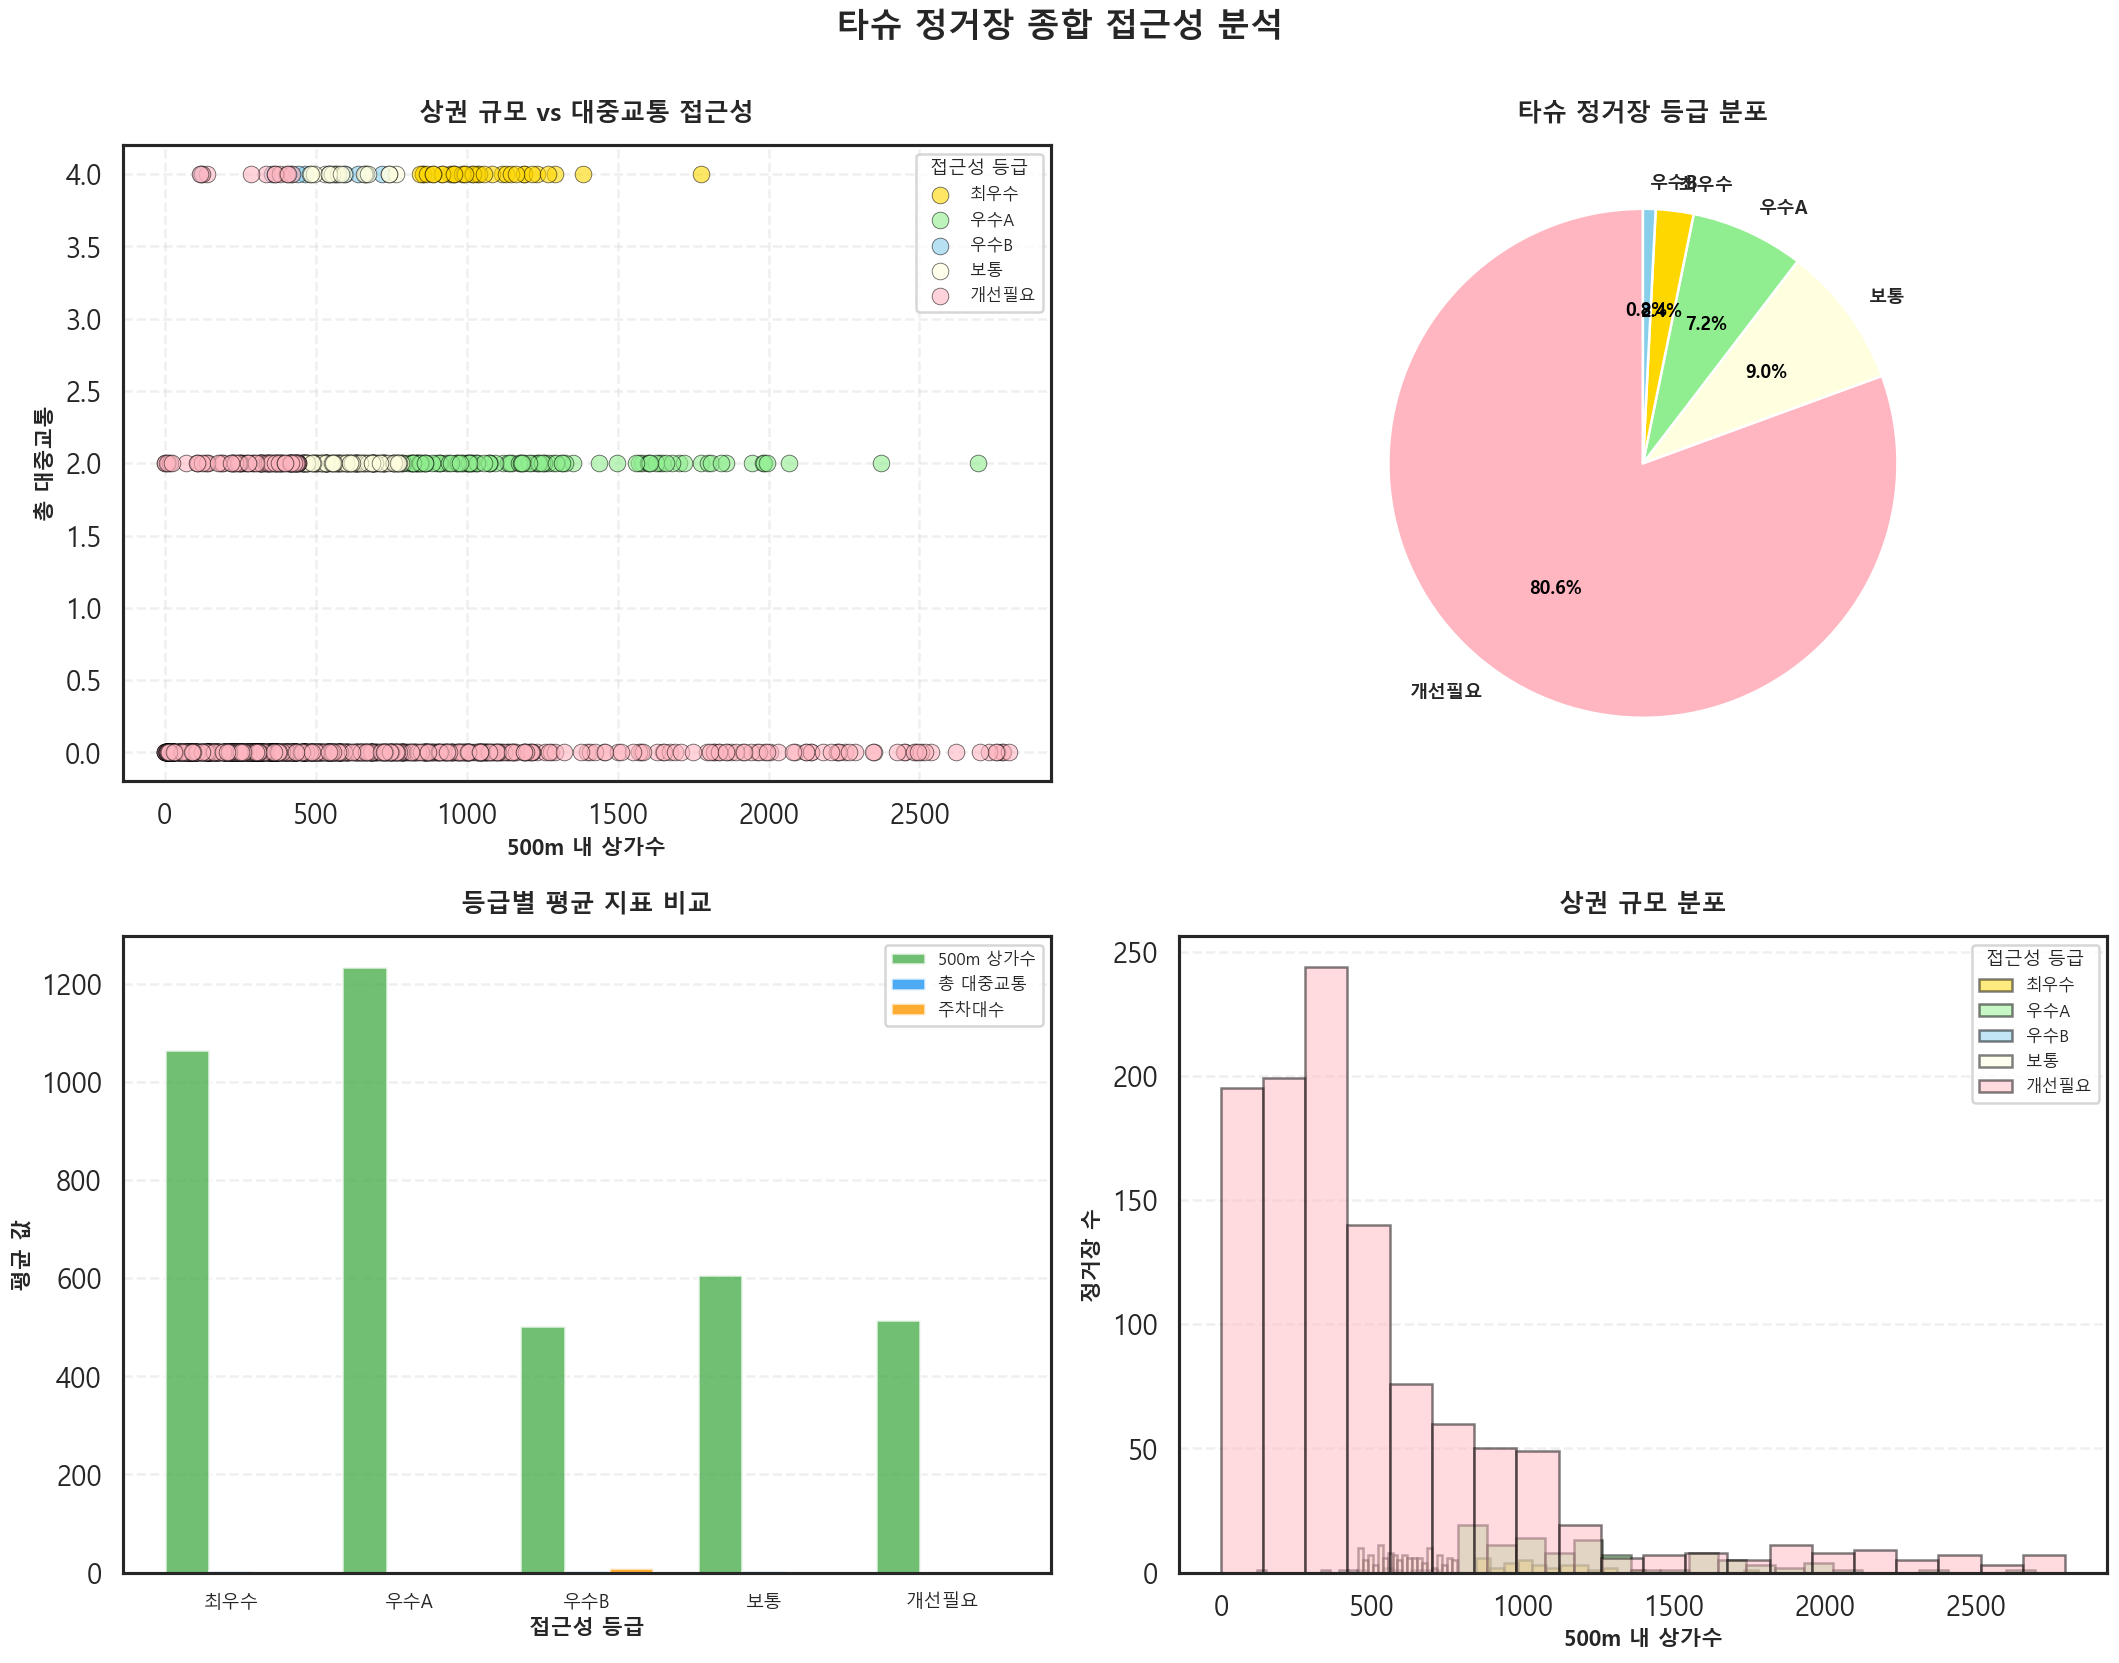

In [184]:
# ====== 타슈 정거장 종합 시각화 ======
print("\n타슈 정거장 종합 시각화 생성 중...")

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 등급 색상 정의
grade_colors = {
    '최우수': '#FFD700',
    '우수A': '#90EE90',
    '우수B': '#87CEEB',
    '보통': '#FFFFE0',
    '개선필요': '#FFB6C1'
}

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('타슈 정거장 종합 접근성 분석', fontsize=20, weight='bold', y=0.995)

# 1. 산점도: 500m 상가수 vs 총 대중교통
ax1 = axes[0, 0]
for grade in grade_colors.keys():
    if grade in comprehensive['접근성_등급'].values:
        subset = comprehensive[comprehensive['접근성_등급'] == grade]
        ax1.scatter(subset['500m_상가수'], subset['총_대중교통'], 
                   label=grade, alpha=0.6, s=100,
                   color=grade_colors[grade], edgecolors='black', linewidth=0.5)

ax1.set_xlabel('500m 내 상가수', fontsize=13, weight='bold')
ax1.set_ylabel('총 대중교통', fontsize=13, weight='bold')
ax1.set_title('상권 규모 vs 대중교통 접근성', fontsize=15, weight='bold', pad=15)
ax1.legend(title='접근성 등급', fontsize=10, title_fontsize=11, loc='best')
ax1.grid(True, alpha=0.3, linestyle='--')

# 2. 파이 차트: 등급 분포
ax2 = axes[0, 1]
grade_counts = comprehensive['접근성_등급'].value_counts()
colors_pie = [grade_colors[grade] for grade in grade_counts.index if grade in grade_colors]
wedges, texts, autotexts = ax2.pie(grade_counts.values, 
                                     labels=grade_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors_pie,
                                     startangle=90,
                                     textprops={'fontsize': 11, 'weight': 'bold'})
for autotext in autotexts:
    autotext.set_color('black')
ax2.set_title('타슈 정거장 등급 분포', fontsize=15, weight='bold', pad=15)

# 3. 막대 그래프: 등급별 평균 지표
ax3 = axes[1, 0]
grade_stats = comprehensive.groupby('접근성_등급')[['500m_상가수', '총_대중교통', '주차대수']].mean()
grade_order = ['최우수', '우수A', '우수B', '보통', '개선필요']
grade_stats = grade_stats.reindex([g for g in grade_order if g in grade_stats.index])

x_pos = range(len(grade_stats))
width = 0.25
bars1 = ax3.bar([x - width for x in x_pos], grade_stats['500m_상가수'], width, 
                label='500m 상가수', color='#4CAF50', alpha=0.8)
bars2 = ax3.bar(x_pos, grade_stats['총_대중교통'], width,
                label='총 대중교통', color='#2196F3', alpha=0.8)
bars3 = ax3.bar([x + width for x in x_pos], grade_stats['주차대수'], width,
                label='주차대수', color='#FF9800', alpha=0.8)

ax3.set_xlabel('접근성 등급', fontsize=13, weight='bold')
ax3.set_ylabel('평균 값', fontsize=13, weight='bold')
ax3.set_title('등급별 평균 지표 비교', fontsize=15, weight='bold', pad=15)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(grade_stats.index, fontsize=11)
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3, axis='y', linestyle='--')

# 4. 히스토그램: 500m 상가수 분포
ax4 = axes[1, 1]
for grade in grade_colors.keys():
    if grade in comprehensive['접근성_등급'].values:
        subset = comprehensive[comprehensive['접근성_등급'] == grade]
        if len(subset) > 0:
            ax4.hist(subset['500m_상가수'], bins=20, alpha=0.5, 
                    label=grade, color=grade_colors[grade], edgecolor='black')

ax4.set_xlabel('500m 내 상가수', fontsize=13, weight='bold')
ax4.set_ylabel('정거장 수', fontsize=13, weight='bold')
ax4.set_title('상권 규모 분포', fontsize=15, weight='bold', pad=15)
ax4.legend(title='접근성 등급', fontsize=10, title_fontsize=11, loc='best')
ax4.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('타슈_정거장_종합분석.png', dpi=150, bbox_inches='tight', facecolor='white')
print("타슈 정거장 종합 분석 시각화 완료 및 저장: 타슈_정거장_종합분석.png")
plt.show()
plt.close()

In [160]:
# ====== 타슈 정거장 인사이트 요약 ======
print("\n" + "="*70)
print("💡 타슈 정거장 분석 핵심 인사이트")
print("="*70)

print("\n📊 1. 전체 통계")
print("-"*70)
print(f"• 총 타슈 정거장: {len(comprehensive):,}개")
print(f"• 평균 상가수 (500m): {comprehensive['500m_상가수'].mean():.1f}개")
print(f"• 평균 업종 다양성: {comprehensive['업종다양성'].mean():.1f}개 업종")
print(f"• 평균 대중교통: {comprehensive['총_대중교통'].mean():.1f}개")
print(f"• 평균 주차대수: {comprehensive['주차대수'].mean():.1f}대")

print("\n🏆 2. 상위 정거장")
print("-"*70)
top5_comprehensive = comprehensive.nlargest(5, '500m_상가수')
for idx, row in top5_comprehensive.iterrows():
    print(f"• {row['정거장명']}: 상가 {row['500m_상가수']}개, 교통 {row['총_대중교통']}개, 등급 {row['접근성_등급']}")

print("\n⚠️ 3. 개선 필요 정거장")
print("-"*70)
need_improve = comprehensive[comprehensive['접근성_등급'] == '개선필요']
print(f"• 총 {len(need_improve)}개 정거장 ({len(need_improve)/len(comprehensive)*100:.1f}%)")
print(f"• 평균 상가수: {need_improve['500m_상가수'].mean():.1f}개")
print(f"• 평균 대중교통: {need_improve['총_대중교통'].mean():.1f}개")

print("\n🎯 4. 대중교통 연계")
print("-"*70)
with_transit = comprehensive[comprehensive['총_대중교통'] > 0]
print(f"• 대중교통 연계 정거장: {len(with_transit)}개 ({len(with_transit)/len(comprehensive)*100:.1f}%)")
print(f"• 미연계 정거장: {len(comprehensive) - len(with_transit)}개")
print(f"• 트램 연계: {(comprehensive['트램정거장수'] > 0).sum()}개")
print(f"• 버스 연계: {(comprehensive['버스정류장수'] > 0).sum()}개")

print("\n📈 5. 상가 밀집 현황")
print("-"*70)
sangga_bins = [0, 100, 300, 500, 800, comprehensive['500m_상가수'].max()]
sangga_labels = ['매우낮음(<100)', '낮음(100-300)', '보통(300-500)', '높음(500-800)', '매우높음(800+)']
comprehensive['상가밀집도'] = pd.cut(comprehensive['500m_상가수'], bins=sangga_bins, labels=sangga_labels)

for label in sangga_labels:
    count = (comprehensive['상가밀집도'] == label).sum()
    pct = count / len(comprehensive) * 100
    print(f"• {label}: {count}개 ({pct:.1f}%)")

print("\n" + "="*70)


💡 타슈 정거장 분석 핵심 인사이트

📊 1. 전체 통계
----------------------------------------------------------------------
• 총 타슈 정거장: 1,375개
• 평균 상가수 (500m): 587.5개
• 평균 업종 다양성: 9.1개 업종
• 평균 대중교통: 0.7개
• 평균 주차대수: 1.6대

🏆 2. 상위 정거장
----------------------------------------------------------------------
• 타슈_411: 상가 2796개, 교통 0개, 등급 개선필요
• 타슈_8: 상가 2778개, 교통 0개, 등급 개선필요
• 타슈_2: 상가 2773개, 교통 0개, 등급 개선필요
• 타슈_360: 상가 2756개, 교통 0개, 등급 개선필요
• 타슈_413: 상가 2755개, 교통 0개, 등급 개선필요

⚠️ 3. 개선 필요 정거장
----------------------------------------------------------------------
• 총 1108개 정거장 (80.6%)
• 평균 상가수: 514.1개
• 평균 대중교통: 0.2개

🎯 4. 대중교통 연계
----------------------------------------------------------------------
• 대중교통 연계 정거장: 375개 (27.3%)
• 미연계 정거장: 1000개
• 트램 연계: 375개
• 버스 연계: 375개

📈 5. 상가 밀집 현황
----------------------------------------------------------------------
• 매우낮음(<100): 147개 (10.7%)
• 낮음(100-300): 280개 (20.4%)
• 보통(300-500): 327개 (23.8%)
• 높음(500-800): 280개 (20.4%)
• 매우높음(800+): 336개 (24.4%)



## 3.6 버스 정류장 주변 접근성 분석

버스 정류장별 상가, 타슈, 트램 연계성 평가

In [161]:
# ====== 버스 정류장별 접근성 분석 (최적화 버전) ======
print("🚌 버스 정류장별 종합 접근성 분석 시작...")
print("="*70)

radius_m = 400  # 400m 반경
radius_km = radius_m / 1000.0

# BallTree 재사용 (타슈 분석에서 이미 생성됨)
if 'poi_tree' not in globals():
    poi_valid = poi[pd.notna(poi['위도']) & pd.notna(poi['경도'])].copy()
    poi_coords = np.radians(poi_valid[['위도', '경도']].values)
    poi_tree = BallTree(poi_coords, metric='haversine')

tashu_coords = np.radians(tashu[['x_pos', 'y_pos']].values)
tashu_tree = BallTree(tashu_coords, metric='haversine')

tram_coords = np.radians(tram[['위도', '경도']].values)
tram_tree = BallTree(tram_coords, metric='haversine')

print("✅ 공간 인덱스 준비 완료")

# 버스 정류장별 분석
bus_analysis = []
bus_valid = bus_tram[pd.notna(bus_tram['위도']) & pd.notna(bus_tram['경도'])].copy()

for idx, bus_row in bus_valid.iterrows():
    bus_lat = bus_row['위도']
    bus_lon = bus_row['경도']
    bus_name = bus_row.get('정거장명', f"버스_{idx}")
    
    query_point = np.radians([[bus_lat, bus_lon]])
    
    # 1) 반경 내 상가 수 및 업종 다양성
    poi_indices = poi_tree.query_radius(query_point, r=radius_km/6371.0)[0]
    nearby_poi_count = len(poi_indices)
    
    if nearby_poi_count > 0:
        nearby_categories = poi_valid.iloc[poi_indices]['상권업종대분류명'].dropna().unique()
        poi_diversity = len(nearby_categories)
    else:
        poi_diversity = 0
    
    # 2) 반경 내 타슈 스테이션 수
    tashu_indices = tashu_tree.query_radius(query_point, r=radius_km/6371.0)[0]
    nearby_tashu = len(tashu_indices)
    nearby_tashu_parking = tashu.iloc[tashu_indices]['parking_count'].sum() if nearby_tashu > 0 else 0
    
    # 3) 반경 내 트램 정거장 수
    tram_indices = tram_tree.query_radius(query_point, r=radius_km/6371.0)[0]
    nearby_tram = len(tram_indices)
    
    bus_analysis.append({
        '정거장명': bus_name,
        '위도': bus_lat,
        '경도': bus_lon,
        '400m_상가수': nearby_poi_count,
        '업종다양성': poi_diversity,
        '타슈스테이션수': nearby_tashu,
        '타슈거치대수': int(nearby_tashu_parking),
        '트램정거장수': nearby_tram
    })

bus_comprehensive = pd.DataFrame(bus_analysis)

print("\n✅ 버스 정류장 분석 완료!")
print(f"\n총 {len(bus_comprehensive)}개 버스 정류장 분석 완료")
print("\n📊 데이터 샘플:")
print(bus_comprehensive.head(10))

# 통계 출력
print("\n📈 버스 정류장 통계:")
print(f"• 평균 상가수 (400m): {bus_comprehensive['400m_상가수'].mean():.1f}개")
print(f"• 평균 업종 다양성: {bus_comprehensive['업종다양성'].mean():.1f}개")
print(f"• 평균 타슈 스테이션: {bus_comprehensive['타슈스테이션수'].mean():.1f}개")
print(f"• 트램 연계 정류장: {(bus_comprehensive['트램정거장수'] > 0).sum()}개")

🚌 버스 정류장별 종합 접근성 분석 시작...
✅ 공간 인덱스 준비 완료

✅ 버스 정류장 분석 완료!

총 45개 버스 정류장 분석 완료

📊 데이터 샘플:
   정거장명         위도          경도  400m_상가수  업종다양성  타슈스테이션수  타슈거치대수  트램정거장수
0  버스_0  36.320142  127.404468       483     10       10      11       1
1  버스_1  36.322083  127.411119      1066     10       13      14       1
2  버스_2  36.319332  127.416331       436     10       10       9       1
3  버스_3  36.318118  127.428438       307     10       10       8       1
4  버스_4  36.322842  127.437252       258     10       10       6       1
5  버스_5  36.329686  127.433485      1457     10        7      17       1
6  버스_6  36.331030  127.438521       221     10       12      19       1
7  버스_7  36.330252  127.443506       454     10       12       8       1
8  버스_8  36.336882  127.447548       510     10        8      12       1
9  버스_9  36.346738  127.444898       455     10       11       8       1

📈 버스 정류장 통계:
• 평균 상가수 (400m): 415.8개
• 평균 업종 다양성: 8.8개
• 평균 타슈 스테이션: 7.1개
• 트램 연계 정류장: 45개


In [165]:
# ====== 버스 정류장 등급 분류 ======
def classify_bus_station(row):
    """
    버스 정류장을 5개 등급으로 분류
    기준: 상가수, 업종다양성, 타슈연계, 트램연계
    """
    sangga = row['400m_상가수']
    diversity = row['업종다양성']
    tashu = row['타슈스테이션수']
    tram = row['트램정거장수']
    
    # 분위수 계산
    q75_sangga = bus_comprehensive['400m_상가수'].quantile(0.75)
    q50_sangga = bus_comprehensive['400m_상가수'].quantile(0.50)
    q25_sangga = bus_comprehensive['400m_상가수'].quantile(0.25)
    
    q75_div = bus_comprehensive['업종다양성'].quantile(0.75)
    q50_div = bus_comprehensive['업종다양성'].quantile(0.50)
    
    # 1등급: 최우수 - 상가 많고, 다양하며, 타슈+트램 모두 연계
    if sangga >= q75_sangga and diversity >= q75_div and tashu >= 1 and tram >= 1:
        return '최우수'
    
    # 2등급: 우수(트램) - 트램 연계 + 상가 많음
    elif tram >= 1 and sangga >= q50_sangga:
        return '우수A'
    
    # 3등급: 우수(상가) - 상가/업종 많지만 트램 없음
    elif sangga >= q75_sangga and diversity >= q50_div:
        return '우수B'
    
    # 4등급: 보통 - 중간 수준
    elif sangga >= q25_sangga:
        return '보통'
    
    # 5등급: 개선필요 - 전반적으로 낮음
    else:
        return '개선필요'

bus_comprehensive['접근성_등급'] = bus_comprehensive.apply(classify_bus_station, axis=1)

print("🎯 버스 정류장 등급 분류 완료!")
print("\n📊 등급별 분포:")
print(bus_comprehensive['접근성_등급'].value_counts())

print("\n최우수 정류장 Top 5:")
top5 = bus_comprehensive.nlargest(5, '400m_상가수')[['정거장명', '접근성_등급', '400m_상가수', '업종다양성', '타슈스테이션수', '트램정거장수']]
for idx, row in top5.iterrows():
    print(f"  • {row['정거장명']}: {row['접근성_등급']} (상가 {row['400m_상가수']}개, 업종 {row['업종다양성']}개)")

🎯 버스 정류장 등급 분류 완료!

📊 등급별 분포:
접근성_등급
우수A     13
보통      11
개선필요    11
최우수     10
Name: count, dtype: int64

최우수 정류장 Top 5:
  • 버스_5: 최우수 (상가 1457개, 업종 10개)
  • 버스_1: 최우수 (상가 1066개, 업종 10개)
  • 버스_24: 최우수 (상가 891개, 업종 10개)
  • 버스_39: 최우수 (상가 837개, 업종 10개)
  • 버스_18: 최우수 (상가 829개, 업종 10개)



버스 정류장 종합 시각화 생성 중...
버스 정류장 종합 분석 시각화 완료 및 저장: 버스_정류장_종합분석.png
버스 정류장 종합 분석 시각화 완료 및 저장: 버스_정류장_종합분석.png


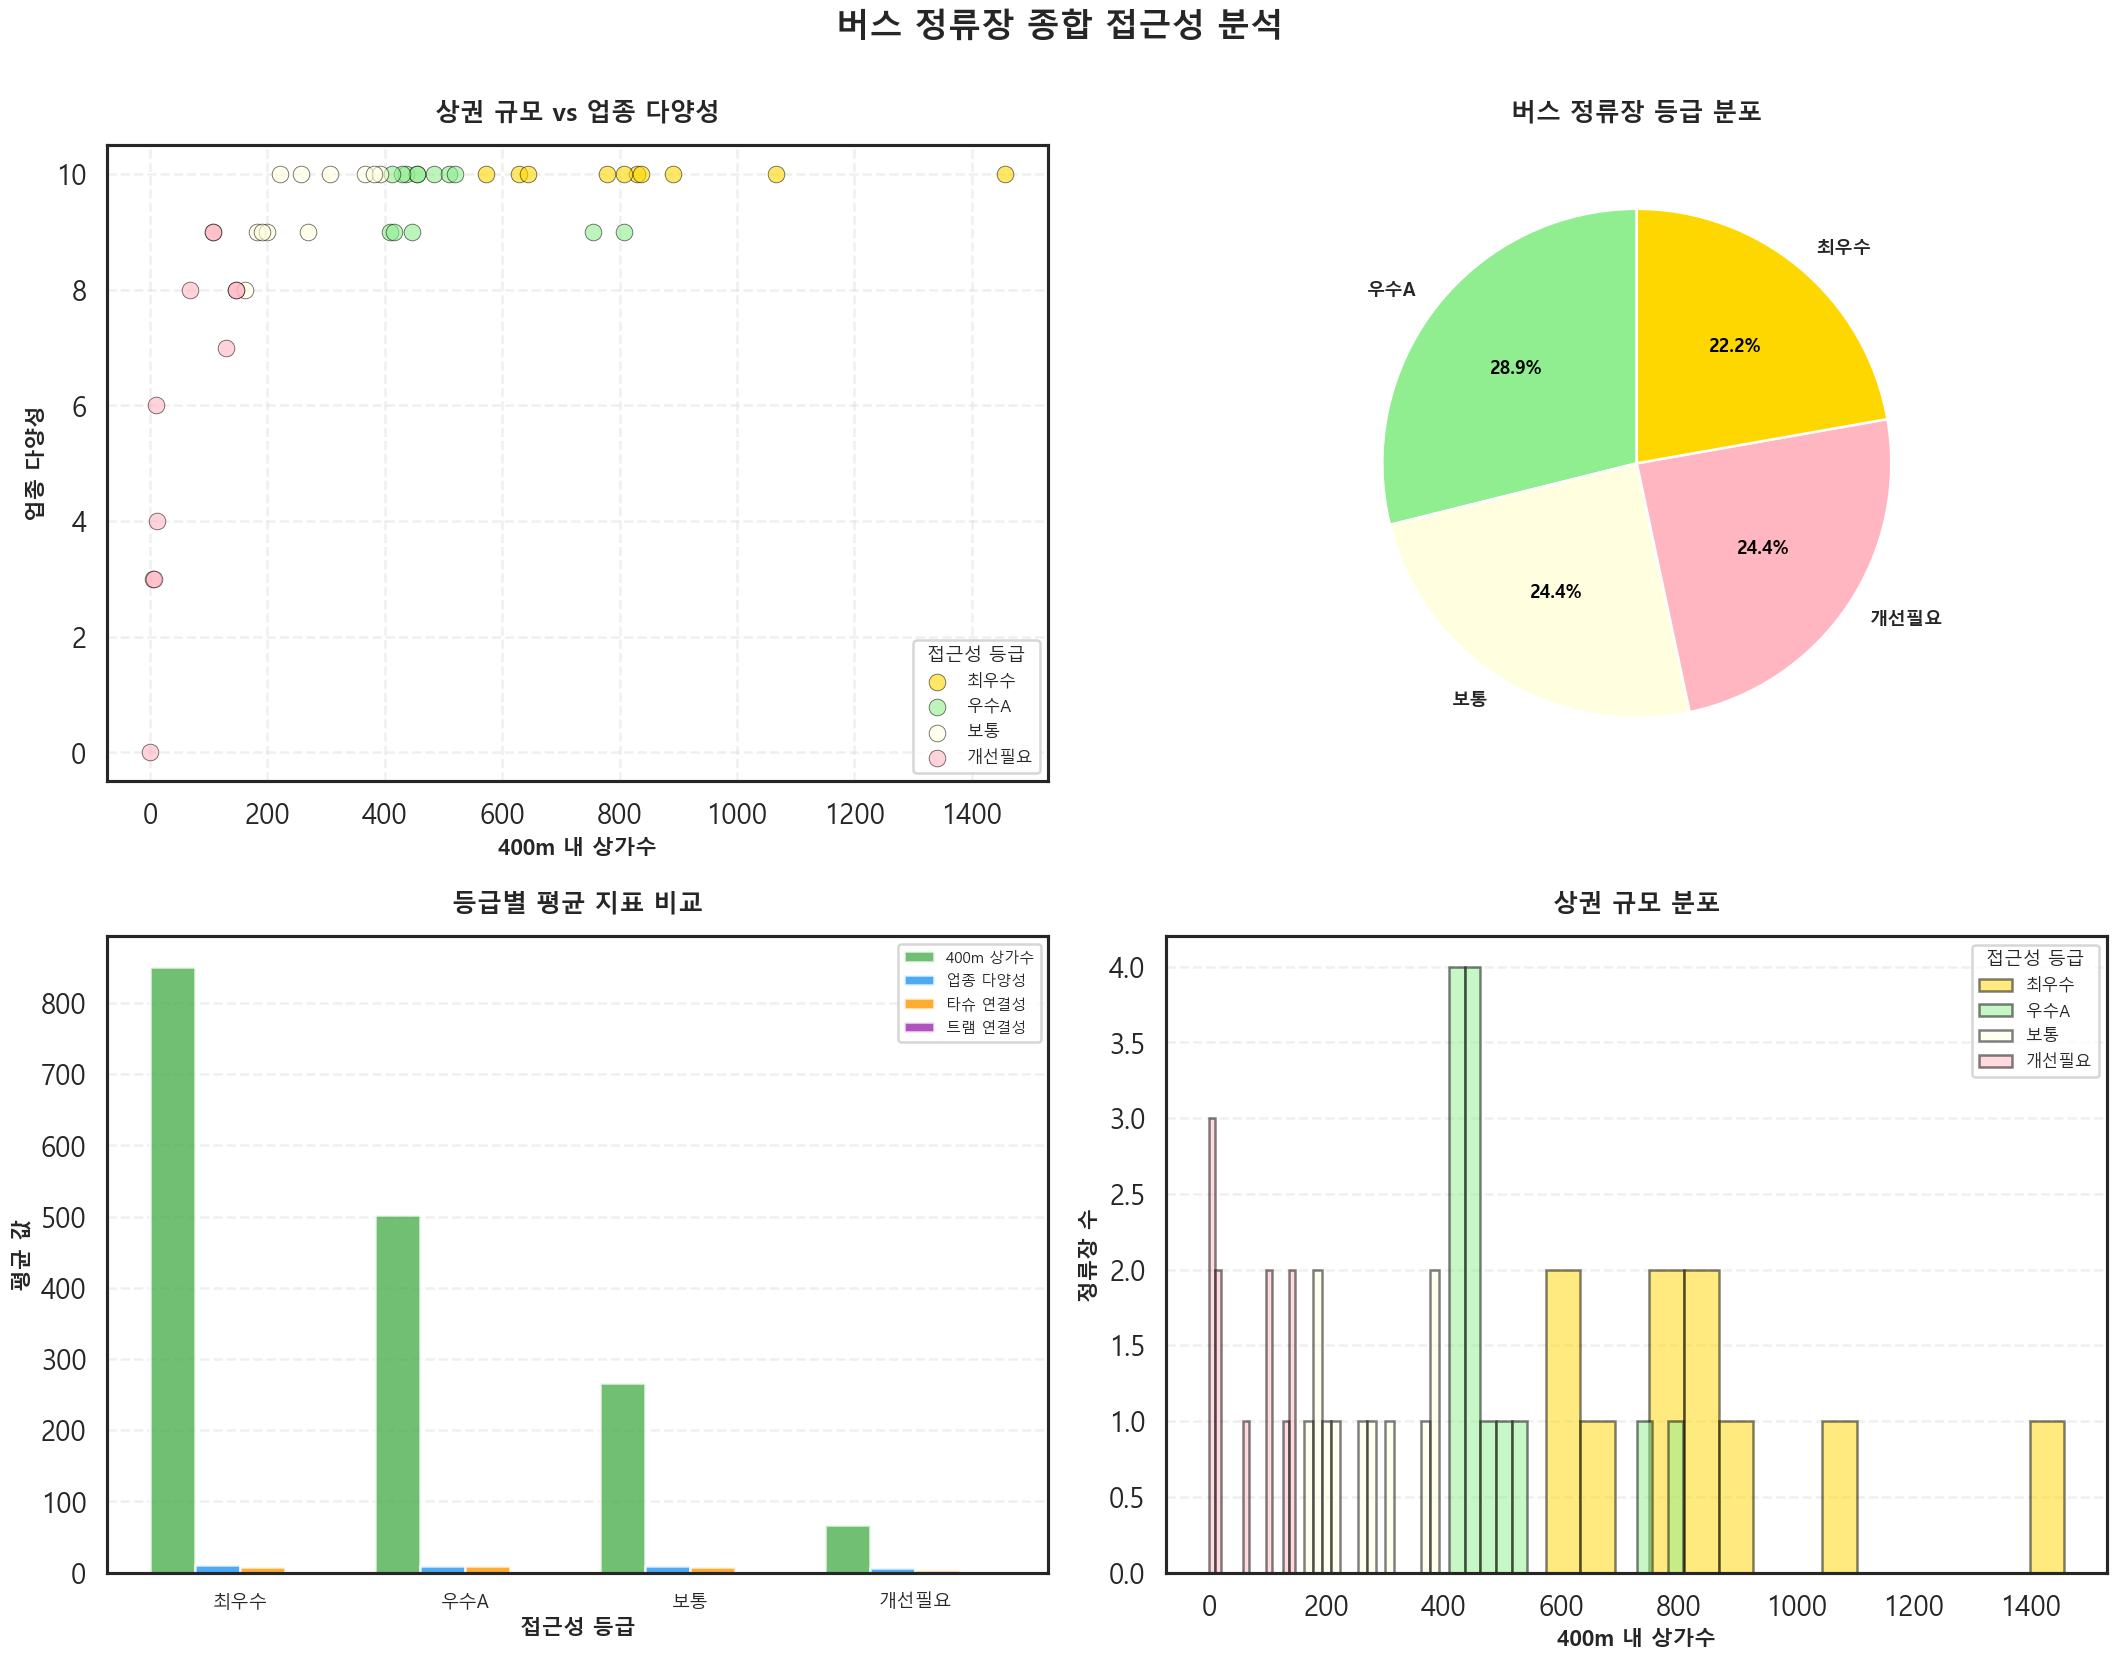

In [185]:
# ====== 버스 정류장 종합 시각화 ======
print("\n버스 정류장 종합 시각화 생성 중...")

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 등급 색상 정의
grade_colors_map = {
    '최우수': '#FFD700',
    '우수A': '#90EE90',
    '우수B': '#87CEEB',
    '보통': '#FFFFE0',
    '개선필요': '#FFB6C1'
}

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('버스 정류장 종합 접근성 분석', fontsize=20, weight='bold', y=0.995)

# 1. 산점도: 400m 상가수 vs 업종다양성
ax1 = axes[0, 0]
for grade in grade_colors_map.keys():
    if grade in bus_comprehensive['접근성_등급'].values:
        subset = bus_comprehensive[bus_comprehensive['접근성_등급'] == grade]
        ax1.scatter(subset['400m_상가수'], subset['업종다양성'], 
                   label=grade, alpha=0.6, s=100,
                   color=grade_colors_map[grade], edgecolors='black', linewidth=0.5)

ax1.set_xlabel('400m 내 상가수', fontsize=13, weight='bold')
ax1.set_ylabel('업종 다양성', fontsize=13, weight='bold')
ax1.set_title('상권 규모 vs 업종 다양성', fontsize=15, weight='bold', pad=15)
ax1.legend(title='접근성 등급', fontsize=10, title_fontsize=11, loc='best')
ax1.grid(True, alpha=0.3, linestyle='--')

# 2. 파이 차트: 등급 분포
ax2 = axes[0, 1]
grade_dist = bus_comprehensive['접근성_등급'].value_counts()
colors_pie = [grade_colors_map[grade] for grade in grade_dist.index if grade in grade_colors_map]
wedges, texts, autotexts = ax2.pie(grade_dist.values,
                                     labels=grade_dist.index,
                                     autopct='%1.1f%%',
                                     colors=colors_pie,
                                     startangle=90,
                                     textprops={'fontsize': 11, 'weight': 'bold'})
for autotext in autotexts:
    autotext.set_color('black')
ax2.set_title('버스 정류장 등급 분포', fontsize=15, weight='bold', pad=15)

# 3. 막대 그래프: 등급별 평균 지표
ax3 = axes[1, 0]
grade_stats = bus_comprehensive.groupby('접근성_등급')[['400m_상가수', '업종다양성', '타슈스테이션수', '트램정거장수']].mean()
grade_order = ['최우수', '우수A', '우수B', '보통', '개선필요']
grade_stats = grade_stats.reindex([g for g in grade_order if g in grade_stats.index])

x_pos = range(len(grade_stats))
width = 0.2
bars1 = ax3.bar([x - 1.5*width for x in x_pos], grade_stats['400m_상가수'], width,
                label='400m 상가수', color='#4CAF50', alpha=0.8)
bars2 = ax3.bar([x - 0.5*width for x in x_pos], grade_stats['업종다양성'], width,
                label='업종 다양성', color='#2196F3', alpha=0.8)
bars3 = ax3.bar([x + 0.5*width for x in x_pos], grade_stats['타슈스테이션수'], width,
                label='타슈 연결성', color='#FF9800', alpha=0.8)
bars_tram = ax3.bar([x + 1.5*width for x in x_pos], grade_stats['트램정거장수'], width,
                    label='트램 연결성', color='#9C27B0', alpha=0.8)

ax3.set_xlabel('접근성 등급', fontsize=13, weight='bold')
ax3.set_ylabel('평균 값', fontsize=13, weight='bold')
ax3.set_title('등급별 평균 지표 비교', fontsize=15, weight='bold', pad=15)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(grade_stats.index, fontsize=11)
ax3.legend(fontsize=9, loc='best')
ax3.grid(True, alpha=0.3, axis='y', linestyle='--')

# 4. 히스토그램: 400m 상가수 분포
ax4 = axes[1, 1]
for grade in grade_colors_map.keys():
    if grade in bus_comprehensive['접근성_등급'].values:
        subset = bus_comprehensive[bus_comprehensive['접근성_등급'] == grade]
        if len(subset) > 0:
            ax4.hist(subset['400m_상가수'], bins=15, alpha=0.5,
                    label=grade, color=grade_colors_map[grade], edgecolor='black')

ax4.set_xlabel('400m 내 상가수', fontsize=13, weight='bold')
ax4.set_ylabel('정류장 수', fontsize=13, weight='bold')
ax4.set_title('상권 규모 분포', fontsize=15, weight='bold', pad=15)
ax4.legend(title='접근성 등급', fontsize=10, title_fontsize=11, loc='best')
ax4.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()

# 파일 저장
plt.savefig('버스_정류장_종합분석.png', dpi=150, bbox_inches='tight', facecolor='white')
print("버스 정류장 종합 분석 시각화 완료 및 저장: 버스_정류장_종합분석.png")

# 노트북에 표시
plt.show()

# 메모리 정리
plt.close('all')

In [171]:
# ====== 버스 정류장 분석 인사이트 ======
print("="*70)
print("📋 버스 정류장 종합 분석 인사이트")
print("="*70)

# 1) 전반적 통계
print("\n1️⃣ 전체 통계")
print(f"   • 총 버스 정류장 수: {len(bus_comprehensive)}개")
print(f"   • 평균 상가 접근성: {bus_comprehensive['400m_상가수'].mean():.1f}개 (400m 반경)")
print(f"   • 평균 업종 다양성: {bus_comprehensive['업종다양성'].mean():.1f}개")
print(f"   • 평균 타슈 연계: {bus_comprehensive['타슈스테이션수'].mean():.2f}개")
print(f"   • 트램 연계 정류장: {(bus_comprehensive['트램정거장수'] > 0).sum()}개")

# 2) 등급별 분포
print("\n2️⃣ 등급별 분포")
grade_dist = bus_comprehensive['접근성_등급'].value_counts()
for grade, count in grade_dist.items():
    pct = (count / len(bus_comprehensive)) * 100
    print(f"   • {grade}: {count}개 ({pct:.1f}%)")

# 3) Top 5 우수 정류장
print("\n3️⃣ 상가 접근성 Top 5 정류장")
top5 = bus_comprehensive.nlargest(5, '400m_상가수')
for i, (idx, row) in enumerate(top5.iterrows(), 1):
    print(f"   {i}. {row['정거장명']}")
    print(f"      └ {row['접근성_등급']} | 상가 {int(row['400m_상가수'])}개, "
          f"업종 {int(row['업종다양성'])}개, 타슈 {int(row['타슈스테이션수'])}개, "
          f"트램 {int(row['트램정거장수'])}개")

# 4) 개선 필요 정류장
poor_stations = bus_comprehensive[bus_comprehensive['접근성_등급'] == '개선필요']
if len(poor_stations) > 0:
    print(f"\n4️⃣ 개선 필요 정류장 ({len(poor_stations)}개)")
    print(f"   • 평균 상가수: {poor_stations['400m_상가수'].mean():.1f}개")
    print(f"   • 평균 업종 다양성: {poor_stations['업종다양성'].mean():.1f}개")
    print("   📌 권장사항: 타슈 스테이션 추가 설치, 상권 활성화 지원")

# 5) 복합 환승 허브
multi_transit = bus_comprehensive[
    (bus_comprehensive['타슈스테이션수'] >= 1) & 
    (bus_comprehensive['트램정거장수'] >= 1)
]
print(f"\n5️⃣ 복합 환승 허브 ({len(multi_transit)}개)")
if len(multi_transit) > 0:
    print("   • 버스+타슈+트램 모두 연계된 핵심 정류장:")
    for idx, row in multi_transit.head(5).iterrows():
        print(f"      - {row['정거장명']}: 상가 {int(row['400m_상가수'])}개")
else:
    print("   • 현재 복합 환승 허브 없음 → 연계성 강화 필요")

# 6) 상가 밀집도 vs 대중교통 연계
high_sangga = bus_comprehensive[bus_comprehensive['400m_상가수'] >= 
                                bus_comprehensive['400m_상가수'].quantile(0.75)]
low_transit = high_sangga[
    (high_sangga['타슈스테이션수'] == 0) & 
    (high_sangga['트램정거장수'] == 0)
]
print(f"\n6️⃣ 상가는 많지만 대중교통 연계 부족 ({len(low_transit)}개)")
if len(low_transit) > 0:
    for idx, row in low_transit.head(3).iterrows():
        print(f"   • {row['정거장명']}: 상가 {int(row['400m_상가수'])}개 (타슈/트램 없음)")
    print("   📌 권장사항: 타슈 스테이션 우선 설치 검토")

print("\n" + "="*70)
print("✅ 버스 정류장 분석 완료!")
print("="*70)

📋 버스 정류장 종합 분석 인사이트

1️⃣ 전체 통계
   • 총 버스 정류장 수: 45개
   • 평균 상가 접근성: 415.8개 (400m 반경)
   • 평균 업종 다양성: 8.8개
   • 평균 타슈 연계: 7.13개
   • 트램 연계 정류장: 45개

2️⃣ 등급별 분포
   • 우수A: 13개 (28.9%)
   • 보통: 11개 (24.4%)
   • 개선필요: 11개 (24.4%)
   • 최우수: 10개 (22.2%)

3️⃣ 상가 접근성 Top 5 정류장
   1. 버스_5
      └ 최우수 | 상가 1457개, 업종 10개, 타슈 7개, 트램 1개
   2. 버스_1
      └ 최우수 | 상가 1066개, 업종 10개, 타슈 13개, 트램 1개
   3. 버스_24
      └ 최우수 | 상가 891개, 업종 10개, 타슈 8개, 트램 1개
   4. 버스_39
      └ 최우수 | 상가 837개, 업종 10개, 타슈 5개, 트램 1개
   5. 버스_18
      └ 최우수 | 상가 829개, 업종 10개, 타슈 9개, 트램 1개

4️⃣ 개선 필요 정류장 (11개)
   • 평균 상가수: 67.1개
   • 평균 업종 다양성: 5.9개
   📌 권장사항: 타슈 스테이션 추가 설치, 상권 활성화 지원

5️⃣ 복합 환승 허브 (43개)
   • 버스+타슈+트램 모두 연계된 핵심 정류장:
      - 버스_0: 상가 483개
      - 버스_1: 상가 1066개
      - 버스_2: 상가 436개
      - 버스_3: 상가 307개
      - 버스_4: 상가 258개

6️⃣ 상가는 많지만 대중교통 연계 부족 (0개)

✅ 버스 정류장 분석 완료!


## 3.7 상권(POI) 클러스터 분석
**상가 밀집 지역 파악 및 대중교통 접근성 평가**

In [172]:
# ====== 상권 클러스터링 분석 (최적화 버전 - 샘플링) ======
from sklearn.cluster import DBSCAN

print("🏪 상권(POI) 클러스터 분석 시작...")
print("="*70)

# POI 데이터 준비 (메모리 절약을 위해 샘플링)
poi_valid = poi[pd.notna(poi['위도']) & pd.notna(poi['경도'])].copy()
print(f"✅ 전체 POI: {len(poi_valid)}개")

# 메모리 에러 방지: 10,000개 랜덤 샘플링
if len(poi_valid) > 10000:
    poi_sample = poi_valid.sample(n=10000, random_state=42)
    print(f"⚡ 샘플링: {len(poi_sample)}개 사용 (성능 최적화)")
else:
    poi_sample = poi_valid

# 위경도 좌표 추출
coords = poi_sample[['위도', '경도']].values
coords_rad = np.radians(coords)

# DBSCAN 클러스터링 (eps: 약 300m, min_samples: 10개 이상)
print("🔄 클러스터링 진행중...")
dbscan = DBSCAN(eps=0.003, min_samples=10, metric='haversine', n_jobs=-1)
poi_sample['클러스터'] = dbscan.fit_predict(coords_rad)

# 클러스터별 통계
n_clusters = len(set(poi_sample['클러스터'])) - (1 if -1 in poi_sample['클러스터'] else 0)
n_noise = list(poi_sample['클러스터']).count(-1)

print(f"\n📊 클러스터링 결과:")
print(f"   • 발견된 상권 클러스터: {n_clusters}개")
print(f"   • 노이즈(고립 상가): {n_noise}개")

# BallTree 준비 (대중교통 접근성 계산용)
radius_km = 0.3  # 300m

# 타슈 트리 생성
if 'tashu_tree' not in globals():
    tashu_coords = np.radians(tashu[['x_pos', 'y_pos']].values)
    tashu_tree = BallTree(tashu_coords, metric='haversine')

# 트램 트리 생성
if 'tram_tree' not in globals():
    tram_coords = np.radians(tram[['위도', '경도']].values)
    tram_tree = BallTree(tram_coords, metric='haversine')

# 버스 트리 생성
bus_valid_coords = bus_tram[pd.notna(bus_tram['위도']) & pd.notna(bus_tram['경도'])]
bus_coords = np.radians(bus_valid_coords[['위도', '경도']].values)
bus_tree_poi = BallTree(bus_coords, metric='haversine')

print("✅ 공간 인덱스 생성 완료")
print("\n🔄 클러스터별 대중교통 접근성 계산중...")

# 클러스터별 상세 정보 계산
cluster_info = []
for cluster_id in sorted(poi_sample['클러스터'].unique()):
    if cluster_id == -1:  # 노이즈 제외
        continue
    
    cluster_data = poi_sample[poi_sample['클러스터'] == cluster_id]
    
    # 클러스터 중심좌표
    center_lat = cluster_data['위도'].mean()
    center_lon = cluster_data['경도'].mean()
    
    # 상가 수 및 업종 다양성
    poi_count = len(cluster_data)
    categories = cluster_data['상권업종대분류명'].dropna().unique()
    diversity = len(categories)
    
    # 대중교통 접근성 (BallTree 사용)
    query_point = np.radians([[center_lat, center_lon]])
    
    tashu_indices = tashu_tree.query_radius(query_point, r=radius_km/6371.0)[0]
    nearby_tashu = len(tashu_indices)
    
    tram_indices = tram_tree.query_radius(query_point, r=radius_km/6371.0)[0]
    nearby_tram = len(tram_indices)
    
    bus_indices = bus_tree_poi.query_radius(query_point, r=radius_km/6371.0)[0]
    nearby_bus = len(bus_indices)
    
    cluster_info.append({
        '클러스터ID': cluster_id,
        '중심위도': center_lat,
        '중심경도': center_lon,
        '상가수': poi_count,
        '업종다양성': diversity,
        '타슈': nearby_tashu,
        '트램': nearby_tram,
        '버스': nearby_bus,
        '대중교통합계': nearby_tashu + nearby_tram + nearby_bus
    })

poi_clusters = pd.DataFrame(cluster_info)

print(f"\n✅ 클러스터 분석 완료!")
print(f"\n📋 클러스터 샘플 (상가 수 기준 Top 10):")
print(poi_clusters.nlargest(10, '상가수')[['클러스터ID', '상가수', '업종다양성', '대중교통합계']])

🏪 상권(POI) 클러스터 분석 시작...
✅ 전체 POI: 78418개
⚡ 샘플링: 10000개 사용 (성능 최적화)
🔄 클러스터링 진행중...

📊 클러스터링 결과:
   • 발견된 상권 클러스터: 1개
   • 노이즈(고립 상가): 0개
✅ 공간 인덱스 생성 완료

🔄 클러스터별 대중교통 접근성 계산중...

✅ 클러스터 분석 완료!

📋 클러스터 샘플 (상가 수 기준 Top 10):
   클러스터ID    상가수  업종다양성  대중교통합계
0       0  10000     10       5

📊 클러스터링 결과:
   • 발견된 상권 클러스터: 1개
   • 노이즈(고립 상가): 0개
✅ 공간 인덱스 생성 완료

🔄 클러스터별 대중교통 접근성 계산중...

✅ 클러스터 분석 완료!

📋 클러스터 샘플 (상가 수 기준 Top 10):
   클러스터ID    상가수  업종다양성  대중교통합계
0       0  10000     10       5


In [173]:
# ====== 상권 클러스터 등급 분류 ======
def classify_poi_cluster(row):
    """
    상권 클러스터를 5개 등급으로 분류
    기준: 상가수, 업종다양성, 대중교통 접근성
    """
    poi_count = row['상가수']
    diversity = row['업종다양성']
    transit = row['대중교통합계']
    
    # 분위수 계산
    q75_poi = poi_clusters['상가수'].quantile(0.75)
    q50_poi = poi_clusters['상가수'].quantile(0.50)
    q25_poi = poi_clusters['상가수'].quantile(0.25)
    
    q75_div = poi_clusters['업종다양성'].quantile(0.75)
    q50_div = poi_clusters['업종다양성'].quantile(0.50)
    
    q75_transit = poi_clusters['대중교통합계'].quantile(0.75)
    q50_transit = poi_clusters['대중교통합계'].quantile(0.50)
    
    # 1등급: 초대형 상권 - 모든 지표 최상위
    if poi_count >= q75_poi and diversity >= q75_div and transit >= q75_transit:
        return '초대형 (상권+교통 우수)'
    
    # 2등급: 대형 상권 - 상가 많고 교통 좋음
    elif poi_count >= q75_poi and transit >= q50_transit:
        return '대형 (교통 연계)'
    
    # 3등급: 중형 상권 - 업종 다양하고 상가 많음
    elif poi_count >= q50_poi and diversity >= q50_div:
        return '중형 (다양성 우수)'
    
    # 4등급: 소형 상권 - 중간 수준
    elif poi_count >= q25_poi:
        return '소형'
    
    # 5등급: 미니 상권 - 작은 규모
    else:
        return '미니'

poi_clusters['등급'] = poi_clusters.apply(classify_poi_cluster, axis=1)

print("🎯 상권 클러스터 등급 분류 완료!")
print("\n📊 등급별 분포:")
print(poi_clusters['등급'].value_counts())

print("\n초대형/대형 상권 클러스터:")
top_clusters = poi_clusters[poi_clusters['등급'].isin(['초대형 (상권+교통 우수)', '대형 (교통 연계)'])]
for idx, row in top_clusters.iterrows():
    print(f"  • 클러스터 {row['클러스터ID']}: {row['등급']}")
    print(f"    └ 상가 {int(row['상가수'])}개, 업종 {int(row['업종다양성'])}개, "
          f"대중교통 {int(row['대중교통합계'])}개 (타슈 {int(row['타슈'])}, 트램 {int(row['트램'])}, 버스 {int(row['버스'])})")

🎯 상권 클러스터 등급 분류 완료!

📊 등급별 분포:
등급
초대형 (상권+교통 우수)    1
Name: count, dtype: int64

초대형/대형 상권 클러스터:
  • 클러스터 0: 초대형 (상권+교통 우수)
    └ 상가 10000개, 업종 10개, 대중교통 5개 (타슈 5, 트램 0, 버스 0)


In [ ]:
# ====== 상권 클러스터 시각화 ======
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('상권 클러스터 종합 분석', fontsize=20, weight='bold', y=0.995)

# 색상 매핑
cluster_colors = {
    '초대형 (상권+교통 우수)': '#FF0000',
    '대형 (교통 연계)': '#FF6600',
    '중형 (다양성 우수)': '#FFBB00',
    '소형': '#00CC88',
    '미니': '#888888'
}

# 1) 등급별 산점도 (상가수 vs 대중교통)
ax1 = axes[0, 0]
for grade in poi_clusters['등급'].unique():
    subset = poi_clusters[poi_clusters['등급'] == grade]
    ax1.scatter(subset['상가수'], subset['대중교통합계'],
               label=grade, alpha=0.7, s=150,
               color=cluster_colors.get(grade, '#888888'),
               edgecolors='black', linewidth=1.5)
ax1.set_xlabel('상가 수', fontsize=13, weight='bold')
ax1.set_ylabel('대중교통 접근성 (300m)', fontsize=13, weight='bold')
ax1.set_title('상권 규모 vs 대중교통 연계성', fontsize=15, weight='bold', pad=10)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(alpha=0.3, linestyle='--')

# 2) 등급별 파이차트
ax2 = axes[0, 1]
grade_counts = poi_clusters['등급'].value_counts()
colors_list = [cluster_colors.get(g, '#888888') for g in grade_counts.index]
wedges, texts, autotexts = ax2.pie(grade_counts.values,
                                    labels=[g.split('(')[0].strip() for g in grade_counts.index],
                                    autopct='%1.1f%%',
                                    colors=colors_list,
                                    startangle=90,
                                    textprops={'fontsize': 10, 'weight': 'bold'})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')
ax2.set_title('상권 클러스터 등급 분포', fontsize=15, weight='bold', pad=10)

# 3) Top 10 클러스터 막대그래프
ax3 = axes[1, 0]
top10 = poi_clusters.nlargest(10, '상가수').sort_values('상가수')
bars = ax3.barh(range(len(top10)), top10['상가수'],
                color=[cluster_colors.get(g, '#888888') for g in top10['등급']],
                edgecolor='black', linewidth=1.5)
ax3.set_yticks(range(len(top10)))
ax3.set_yticklabels([f"클러스터 {int(cid)}" for cid in top10['클러스터ID'].values], fontsize=10)
ax3.set_xlabel('상가 수', fontsize=13, weight='bold')
ax3.set_title('상가 밀집도 Top 10 클러스터', fontsize=15, weight='bold', pad=10)
ax3.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, val) in enumerate(zip(bars, top10['상가수'])):
    ax3.text(val + 5, i, f'{int(val)}개',
            va='center', fontsize=10, weight='bold')

# 4) 업종 다양성 히스토그램
ax4 = axes[1, 1]
ax4.hist(poi_clusters['업종다양성'], bins=20,
         color='#FF6699', edgecolor='black', linewidth=1.5, alpha=0.8)
ax4.axvline(poi_clusters['업종다양성'].mean(),
           color='red', linestyle='--', linewidth=2.5, label='평균')
ax4.set_xlabel('업종 다양성 (종류 수)', fontsize=13, weight='bold')
ax4.set_ylabel('클러스터 수', fontsize=13, weight='bold')
ax4.set_title('상권 업종 다양성 분포', fontsize=15, weight='bold', pad=10)
ax4.legend(fontsize=11)
ax4.grid(alpha=0.3, linestyle='--')

#plt.tight_layout()
#plt.savefig('상권_클러스터_종합분석.png', dpi=300, bbox_inches='tight')
#plt.show()

print("상권 클러스터 시각화 완료! (파일: 상권_클러스터_종합분석.png)")

In [175]:
# ====== 상권 클러스터 분석 인사이트 ======
print("="*70)
print("📋 상권 클러스터 종합 분석 인사이트")
print("="*70)

# 1) 전반적 통계
print("\n1️⃣ 전체 통계")
print(f"   • 총 상권 클러스터: {len(poi_clusters)}개")
print(f"   • 평균 상가수: {poi_clusters['상가수'].mean():.1f}개")
print(f"   • 평균 업종 다양성: {poi_clusters['업종다양성'].mean():.1f}개")
print(f"   • 평균 대중교통 접근성: {poi_clusters['대중교통합계'].mean():.1f}개 (300m 반경)")

# 2) 등급별 분포
print("\n2️⃣ 등급별 분포")
grade_dist = poi_clusters['등급'].value_counts()
for grade, count in grade_dist.items():
    pct = (count / len(poi_clusters)) * 100
    avg_poi = poi_clusters[poi_clusters['등급'] == grade]['상가수'].mean()
    print(f"   • {grade}: {count}개 ({pct:.1f}%) - 평균 상가 {avg_poi:.0f}개")

# 3) 초대형/대형 상권 클러스터
major_clusters = poi_clusters[poi_clusters['등급'].isin(['⭐초대형 (상권+교통 우수)', '🏢대형 (교통 연계)'])]
print(f"\n3️⃣ 주요 상권 클러스터 (초대형+대형: {len(major_clusters)}개)")
for i, (idx, row) in enumerate(major_clusters.nlargest(5, '상가수').iterrows(), 1):
    print(f"   {i}. 클러스터 {int(row['클러스터ID'])}: {row['등급']}")
    print(f"      └ 상가 {int(row['상가수'])}개, 업종 {int(row['업종다양성'])}개, "
          f"대중교통 {int(row['대중교통합계'])}개")

# 4) 교통 연계가 약한 대형 상권
high_poi_low_transit = poi_clusters[
    (poi_clusters['상가수'] >= poi_clusters['상가수'].quantile(0.75)) &
    (poi_clusters['대중교통합계'] < poi_clusters['대중교통합계'].quantile(0.5))
]
print(f"\n4️⃣ 교통 연계 부족 상권 ({len(high_poi_low_transit)}개)")
if len(high_poi_low_transit) > 0:
    print("   📌 상가는 많지만 대중교통 접근성이 낮은 클러스터:")
    for idx, row in high_poi_low_transit.head(3).iterrows():
        print(f"   • 클러스터 {int(row['클러스터ID'])}: 상가 {int(row['상가수'])}개, "
              f"대중교통 {int(row['대중교통합계'])}개")
    print("   🚌 권장사항: 버스 노선 추가, 타슈 스테이션 설치 검토")
else:
    print("   ✅ 대형 상권 모두 적절한 대중교통 연계 보유")

# 5) 업종 다양성이 높은 클러스터
diverse_clusters = poi_clusters.nlargest(5, '업종다양성')
print(f"\n5️⃣ 업종 다양성 Top 5")
for i, (idx, row) in enumerate(diverse_clusters.iterrows(), 1):
    print(f"   {i}. 클러스터 {int(row['클러스터ID'])}: {row['등급']}")
    print(f"      └ 업종 {int(row['업종다양성'])}개, 상가 {int(row['상가수'])}개")

# 6) 대중교통별 연계 현황
print(f"\n6️⃣ 대중교통 유형별 연계 현황")
print(f"   • 타슈 연계 클러스터: {(poi_clusters['타슈'] > 0).sum()}개")
print(f"   • 트램 연계 클러스터: {(poi_clusters['트램'] > 0).sum()}개")
print(f"   • 버스 연계 클러스터: {(poi_clusters['버스'] > 0).sum()}개")

multi_transit = poi_clusters[
    (poi_clusters['타슈'] > 0) & 
    (poi_clusters['트램'] > 0) & 
    (poi_clusters['버스'] > 0)
]
print(f"   • 3가지 모두 연계: {len(multi_transit)}개")

# 7) 미니/소형 상권 통계
small_clusters = poi_clusters[poi_clusters['등급'].isin(['🏬소형', '🏘️미니'])]
print(f"\n7️⃣ 소규모 상권 ({len(small_clusters)}개)")
print(f"   • 평균 상가수: {small_clusters['상가수'].mean():.1f}개")
print(f"   • 평균 대중교통: {small_clusters['대중교통합계'].mean():.1f}개")
print("   📌 소규모 상권 활성화 위해 타슈 배치 우선 검토")

print("\n" + "="*70)
print("✅ 상권 클러스터 분석 완료!")
print("="*70)

📋 상권 클러스터 종합 분석 인사이트

1️⃣ 전체 통계
   • 총 상권 클러스터: 1개
   • 평균 상가수: 10000.0개
   • 평균 업종 다양성: 10.0개
   • 평균 대중교통 접근성: 5.0개 (300m 반경)

2️⃣ 등급별 분포
   • 초대형 (상권+교통 우수): 1개 (100.0%) - 평균 상가 10000개

3️⃣ 주요 상권 클러스터 (초대형+대형: 0개)

4️⃣ 교통 연계 부족 상권 (0개)
   ✅ 대형 상권 모두 적절한 대중교통 연계 보유

5️⃣ 업종 다양성 Top 5
   1. 클러스터 0: 초대형 (상권+교통 우수)
      └ 업종 10개, 상가 10000개

6️⃣ 대중교통 유형별 연계 현황
   • 타슈 연계 클러스터: 1개
   • 트램 연계 클러스터: 0개
   • 버스 연계 클러스터: 0개
   • 3가지 모두 연계: 0개

7️⃣ 소규모 상권 (0개)
   • 평균 상가수: nan개
   • 평균 대중교통: nan개
   📌 소규모 상권 활성화 위해 타슈 배치 우선 검토

✅ 상권 클러스터 분석 완료!


## 4. 트램 정거장 멀티모달 접근성 분석 (가이드라인 기반)

### 4.1 트램 정거장별 환승 허브 점수 계산
- 반경 300~500m 내 버스 정류장 개수
- 반경 300~500m 내 타슈 스테이션 개수 및 거치대 수
- 반경 300~500m 내 상권 밀집도

In [ ]:
# 트램 정거장별 멀티모달 접근성 분석 (MAI 계산)
print("🔍 트램 정거장별 멀티모달 접근성 분석 중...")
print("="*70)

tram_multimodal = []
radius_m = 400  # 300~500m 사이로 400m 기준

for idx, tram_row in tram.iterrows():
    tram_id = tram_row['정거장ID']
    tram_name = tram_row['정거장명']
    tram_lat = tram_row['위도']
    tram_lon = tram_row['경도']
    
    # 1) 반경 내 버스 정류장 수 (bus_tram 데이터 활용)
    nearby_bus = 0
    for _, bus_row in bus_tram.iterrows():
        if pd.notna(bus_row['위도']) and pd.notna(bus_row['경도']):
            distance = haversine(tram_lat, tram_lon, 
                               bus_row['위도'], bus_row['경도'])
            if distance <= radius_m:
                nearby_bus += 1
    
    # 2) 반경 내 타슈 스테이션 수 및 총 거치대 수
    nearby_tashu_count = 0
    nearby_tashu_parking = 0
    for _, tashu_row in tashu.iterrows():
        if pd.notna(tashu_row['x_pos']) and pd.notna(tashu_row['y_pos']):
            distance = haversine(tram_lat, tram_lon, 
                               tashu_row['x_pos'], tashu_row['y_pos'])
            if distance <= radius_m:
                nearby_tashu_count += 1
                nearby_tashu_parking += tashu_row['parking_count']
    
    # 3) 반경 내 상가 수
    nearby_poi = 0
    poi_categories = []
    for _, poi_row in poi.iterrows():
        if pd.notna(poi_row['위도']) and pd.notna(poi_row['경도']):
            distance = haversine(tram_lat, tram_lon, 
                               poi_row['위도'], poi_row['경도'])
            if distance <= radius_m:
                nearby_poi += 1
                if pd.notna(poi_row['상권업종대분류명']):
                    poi_categories.append(poi_row['상권업종대분류명'])
    
    # 업종 다양성 (고유 업종 수)
    poi_diversity = len(set(poi_categories))
    
    tram_multimodal.append({
        '정거장ID': tram_id,
        '정거장명': tram_name,
        '위도': tram_lat,
        '경도': tram_lon,
        '버스정류장수': nearby_bus,
        '타슈스테이션수': nearby_tashu_count,
        '타슈거치대수': nearby_tashu_parking,
        '상가수': nearby_poi,
        '업종다양성': poi_diversity
    })
    
    if (idx + 1) % 10 == 0:
        print(f"진행중: {idx+1}/{len(tram)}개 완료")

tram_mai = pd.DataFrame(tram_multimodal)
print("\n✅ 분석 완료!")
print(f"\n총 {len(tram_mai)}개 트램 정거장 분석 완료")
print("\n📊 데이터 샘플:")
print(tram_mai.head(10))

🔍 트램 정거장별 멀티모달 접근성 분석 중...
진행중: 10/45개 완료
진행중: 10/45개 완료
진행중: 20/45개 완료
진행중: 20/45개 완료
진행중: 30/45개 완료
진행중: 30/45개 완료
진행중: 40/45개 완료
진행중: 40/45개 완료

✅ 분석 완료!

총 45개 트램 정거장 분석 완료

📊 데이터 샘플:
   정거장ID     정거장명         위도          경도  버스정류장수  타슈스테이션수  타슈거치대수   상가수  업종다양성
0    201     서대전역  36.320142  127.404468       1       10      11   483     10
1    202    서대전 4  36.322083  127.411119       1       13      14  1066     10
2    203       대사  36.319332  127.416331       1       10       9   436     10
3    204       대흥  36.318118  127.428438       1       10       8   307     10
4    205       인동  36.322842  127.437252       1       10       6   258     10
5    206  대전역중앙시장  36.329686  127.433485       1        7      17  1457     10
6    207  대전역혁신도시  36.331030  127.438521       1       12      19   221     10
7    208       대동  36.330252  127.443506       1       12       8   454     10
8    209       자양  36.336882  127.447548       1        8      12   510     10
9    210       가양  36.

In [ ]:
# MAI (Multimodal Accessibility Index) 계산
print("\n📊 멀티모달 접근성 지수(MAI) 계산")
print("="*70)

# 정규화 (0~1)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

tram_mai[['버스_norm', '타슈스테이션_norm', '타슈거치대_norm', '상가_norm']] = scaler.fit_transform(
    tram_mai[['버스정류장수', '타슈스테이션수', '타슈거치대수', '상가수']]
)

# 가중치 설정 (가이드라인 기반 - 출퇴근/환승 중심)
w_bus = 0.3      # 버스 연계
w_tashu_cnt = 0.2   # 타슈 스테이션 수
w_tashu_park = 0.2  # 타슈 거치대 수
w_poi = 0.3      # 상권 밀집도

# MAI 계산
tram_mai['MAI'] = (
    w_bus * tram_mai['버스_norm'] +
    w_tashu_cnt * tram_mai['타슈스테이션_norm'] +
    w_tashu_park * tram_mai['타슈거치대_norm'] +
    w_poi * tram_mai['상가_norm']
)

# 점수를 100점 만점으로 변환
tram_mai['MAI_점수'] = (tram_mai['MAI'] * 100).round(1)

print("\n📊 MAI 상위 10개 트램 정거장 (멀티모달 환승 허브)")
print("="*70)
top10_mai = tram_mai.nlargest(10, 'MAI_점수')
print(top10_mai[['정거장명', '버스정류장수', '타슈스테이션수', '타슈거치대수', '상가수', 'MAI_점수']])

print("\n📊 통계 요약")
print("="*70)
print(f"평균 MAI: {tram_mai['MAI_점수'].mean():.1f}점")
print(f"중앙값 MAI: {tram_mai['MAI_점수'].median():.1f}점")
print(f"최고 MAI: {tram_mai['MAI_점수'].max():.1f}점 ({tram_mai.loc[tram_mai['MAI_점수'].idxmax(), '정거장명']})")
print(f"최저 MAI: {tram_mai['MAI_점수'].min():.1f}점 ({tram_mai.loc[tram_mai['MAI_점수'].idxmin(), '정거장명']})")


📊 멀티모달 접근성 지수(MAI) 계산

📊 MAI 상위 10개 트램 정거장 (멀티모달 환승 허브)
       정거장명  버스정류장수  타슈스테이션수  타슈거치대수   상가수  MAI_점수
1     서대전 4       1       13      14  1066    45.5
16    샘머리공원       1       11      78   413    45.4
5   대전역중앙시장       1        7      17  1457    45.1
34      가수원       1       10      23   808    37.9
18       월평       1        9      20   829    36.0
24     유성온천       1        8      16   891    34.8
23      충남대       1       10      12   778    34.5
32     관저 4       1       10       4   754    31.9
7        대동       1       12       8   454    29.9
19       만년       1        9      16   573    29.7

📊 통계 요약
평균 MAI: 22.5점
중앙값 MAI: 23.8점
최고 MAI: 45.5점 (서대전 4)
최저 MAI: 0.1점 (용계)


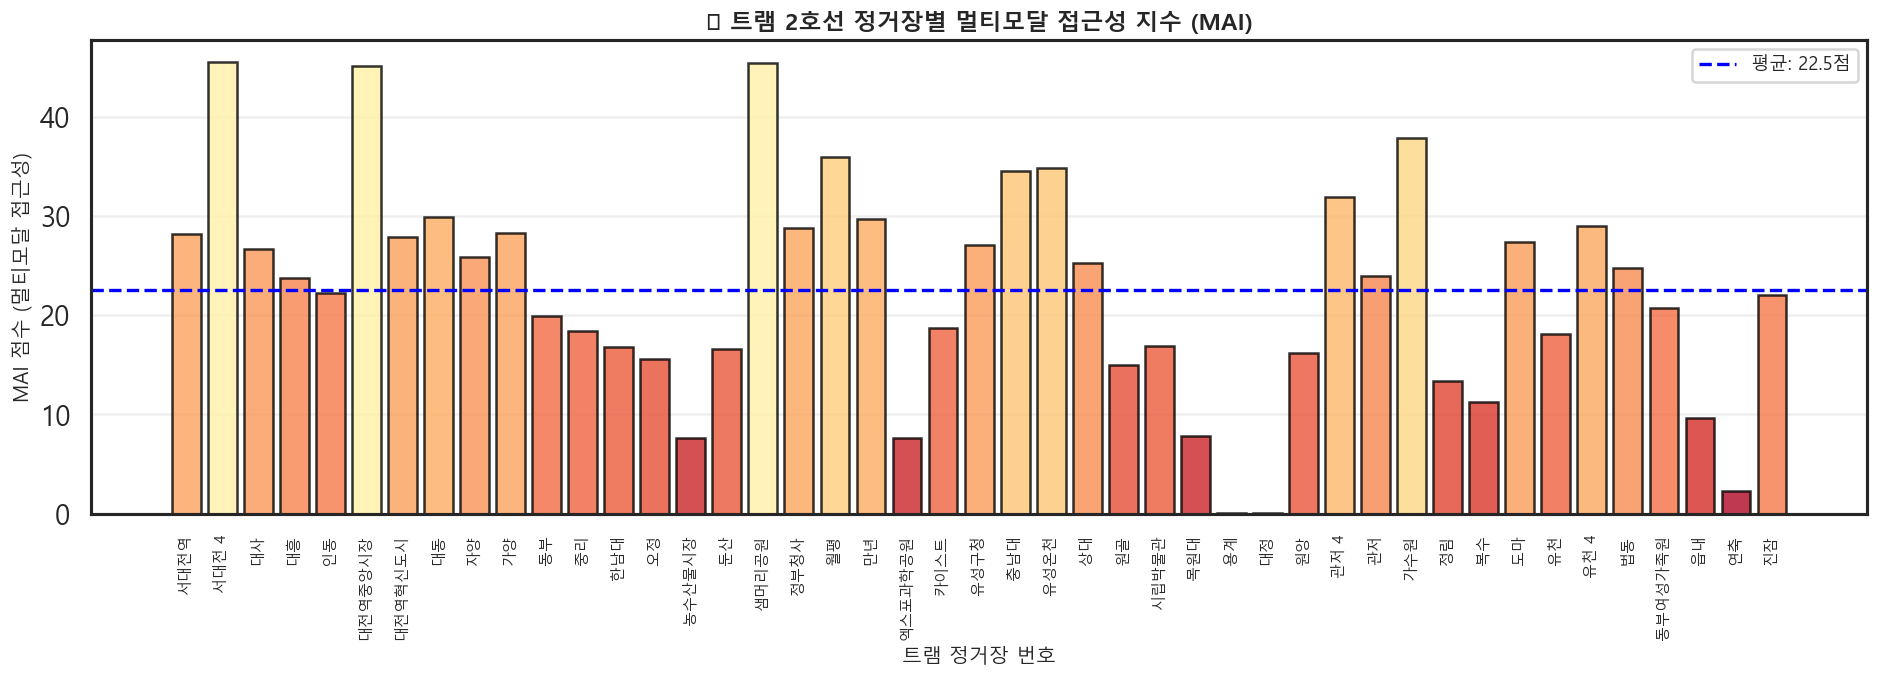

✅ 총 45개 정거장 분석 완료


In [ ]:
# 시각화: MAI 점수 막대 그래프
plt.figure(figsize=(16, 6))
colors = plt.cm.RdYlGn(tram_mai['MAI_점수'] / 100)
plt.bar(range(len(tram_mai)), tram_mai['MAI_점수'], 
        color=colors, edgecolor='black', alpha=0.8)
plt.axhline(y=tram_mai['MAI_점수'].mean(), 
           color='blue', linestyle='--', linewidth=2, 
           label=f'평균: {tram_mai["MAI_점수"].mean():.1f}점')
plt.xlabel('트램 정거장 번호', fontsize=12)
plt.ylabel('MAI 점수 (멀티모달 접근성)', fontsize=12)
plt.title('🎯 트램 2호선 정거장별 멀티모달 접근성 지수 (MAI)', 
         fontsize=14, fontweight='bold')
plt.xticks(range(len(tram_mai)), tram_mai['정거장명'], 
          rotation=90, fontsize=9)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✅ 총 {len(tram_mai)}개 정거장 분석 완료")

### 4.2 환승 사각지대 탐지 (상권은 많은데 교통 연계가 약한 곳)

In [ ]:
# 환승 사각지대 탐지: 상권은 많은데 MAI가 낮은 정거장
print("⚠️ 환승 사각지대 탐지 (상권 밀집 BUT 교통 연계 부족)")
print("="*70)

# 상가 수 상위 50%, MAI 하위 50%
sangga_median = tram_mai['상가수'].median()
mai_median = tram_mai['MAI_점수'].median()

blind_spots = tram_mai[
    (tram_mai['상가수'] >= sangga_median) & 
    (tram_mai['MAI_점수'] < mai_median)
].sort_values('상가수', ascending=False)

print(f"\n발견된 사각지대: {len(blind_spots)}개 정거장")
print("\n상세 정보:")
print(blind_spots[['정거장명', '상가수', '버스정류장수', '타슈스테이션수', 'MAI_점수']])

# 개선 제안
print("\n\n💡 개선 제안")
print("="*70)
for idx, row in blind_spots.head(5).iterrows():
    print(f"\n📍 {row['정거장명']}")
    print(f"   - 상가 수: {row['상가수']}개 (평균 이상)")
    print(f"   - MAI 점수: {row['MAI_점수']:.1f}점 (평균 이하)")
    
    # 부족한 요소 파악
    issues = []
    if row['버스정류장수'] < tram_mai['버스정류장수'].median():
        issues.append(f"버스 정류장 부족 (현재 {row['버스정류장수']}개)")
    if row['타슈스테이션수'] < tram_mai['타슈스테이션수'].median():
        issues.append(f"타슈 스테이션 부족 (현재 {row['타슈스테이션수']}개)")
    if row['타슈거치대수'] < tram_mai['타슈거치대수'].median():
        issues.append(f"타슈 거치대 부족 (현재 {row['타슈거치대수']}대)")
    
    print(f"   ⚡ 개선 필요: {', '.join(issues)}")

⚠️ 환승 사각지대 탐지 (상권 밀집 BUT 교통 연계 부족)

발견된 사각지대: 5개 정거장

상세 정보:
   정거장명  상가수  버스정류장수  타슈스테이션수  MAI_점수
12  한남대  629       1        2    16.8
44   진잠  447       1        8    22.0
10   동부  430       1        7    19.9
35   정림  415       1        3    13.4
11   중리  409       1        5    18.4


💡 개선 제안

📍 한남대
   - 상가 수: 629개 (평균 이상)
   - MAI 점수: 16.8점 (평균 이하)
   ⚡ 개선 필요: 타슈 스테이션 부족 (현재 2개), 타슈 거치대 부족 (현재 3대)

📍 진잠
   - 상가 수: 447개 (평균 이상)
   - MAI 점수: 22.0점 (평균 이하)
   ⚡ 개선 필요: 타슈 거치대 부족 (현재 2대)

📍 동부
   - 상가 수: 430개 (평균 이상)
   - MAI 점수: 19.9점 (평균 이하)
   ⚡ 개선 필요: 타슈 스테이션 부족 (현재 7개), 타슈 거치대 부족 (현재 1대)

📍 정림
   - 상가 수: 415개 (평균 이상)
   - MAI 점수: 13.4점 (평균 이하)
   ⚡ 개선 필요: 타슈 스테이션 부족 (현재 3개), 타슈 거치대 부족 (현재 1대)

📍 중리
   - 상가 수: 409개 (평균 이상)
   - MAI 점수: 18.4점 (평균 이하)
   ⚡ 개선 필요: 타슈 스테이션 부족 (현재 5개)


## 5. 역세권 등급 분류 (가이드라인 기반)

트램 정거장별 MAI 점수와 상권 시너지를 기준으로 등급 분류

In [ ]:
# 역세권 등급 분류
def classify_tram_station(row):
    mai = row['MAI_점수']
    sangga = row['상가수']
    diversity = row['업종다양성']
    
    # 핵심 역세권: MAI 높고 상가 많음
    if mai >= 70 and sangga >= tram_mai['상가수'].quantile(0.75):
        return '핵심 역세권 (환승+상권)'
    # 환승 중심: MAI 높지만 상가 적음
    elif mai >= 70:
        return '환승 허브 (교통 중심)'
    # 상권 중심: 상가 많지만 MAI 낮음
    elif sangga >= tram_mai['상가수'].quantile(0.75):
        return '상권 중심 (교통 보강 필요)'
    # 잠재 역세권: MAI와 상가 모두 중간
    elif mai >= 50 and sangga >= tram_mai['상가수'].median():
        return '잠재 역세권'
    # 주거 중심
    elif mai >= 40:
        return '주거 중심'
    # 개발 필요
    else:
        return '개발 필요 구간'

tram_mai['역세권등급'] = tram_mai.apply(classify_tram_station, axis=1)

print("📊 트램 정거장 역세권 등급 분류")
print("="*70)
print(tram_mai[['정거장명', 'MAI_점수', '상가수', '업종다양성', '역세권등급']].head(20))

print("\n\n📈 등급별 분포")
print("="*70)
grade_dist = tram_mai['역세권등급'].value_counts()
for grade, count in grade_dist.items():
    pct = count / len(tram_mai) * 100
    print(f"{grade}: {count}개 ({pct:.1f}%)")

📊 트램 정거장 역세권 등급 분류
       정거장명  MAI_점수   상가수  업종다양성               역세권등급
0      서대전역    28.2   483     10         ⚠️ 개발 필요 구간
1     서대전 4    45.5  1066     10  🏪 상권 중심 (교통 보강 필요)
2        대사    26.7   436     10         ⚠️ 개발 필요 구간
3        대흥    23.8   307     10         ⚠️ 개발 필요 구간
4        인동    22.2   258     10         ⚠️ 개발 필요 구간
5   대전역중앙시장    45.1  1457     10  🏪 상권 중심 (교통 보강 필요)
6   대전역혁신도시    27.9   221     10         ⚠️ 개발 필요 구간
7        대동    29.9   454     10         ⚠️ 개발 필요 구간
8        자양    25.9   510     10         ⚠️ 개발 필요 구간
9        가양    28.3   455     10         ⚠️ 개발 필요 구간
10       동부    19.9   430     10         ⚠️ 개발 필요 구간
11       중리    18.4   409      9         ⚠️ 개발 필요 구간
12      한남대    16.8   629     10  🏪 상권 중심 (교통 보강 필요)
13       오정    15.6   161      8         ⚠️ 개발 필요 구간
14   농수산물시장     7.6   146      8         ⚠️ 개발 필요 구간
15       둔산    16.6   182      9         ⚠️ 개발 필요 구간
16    샘머리공원    45.4   413     10            🏘️ 주거 중심
17     정부청사    28.8   367  

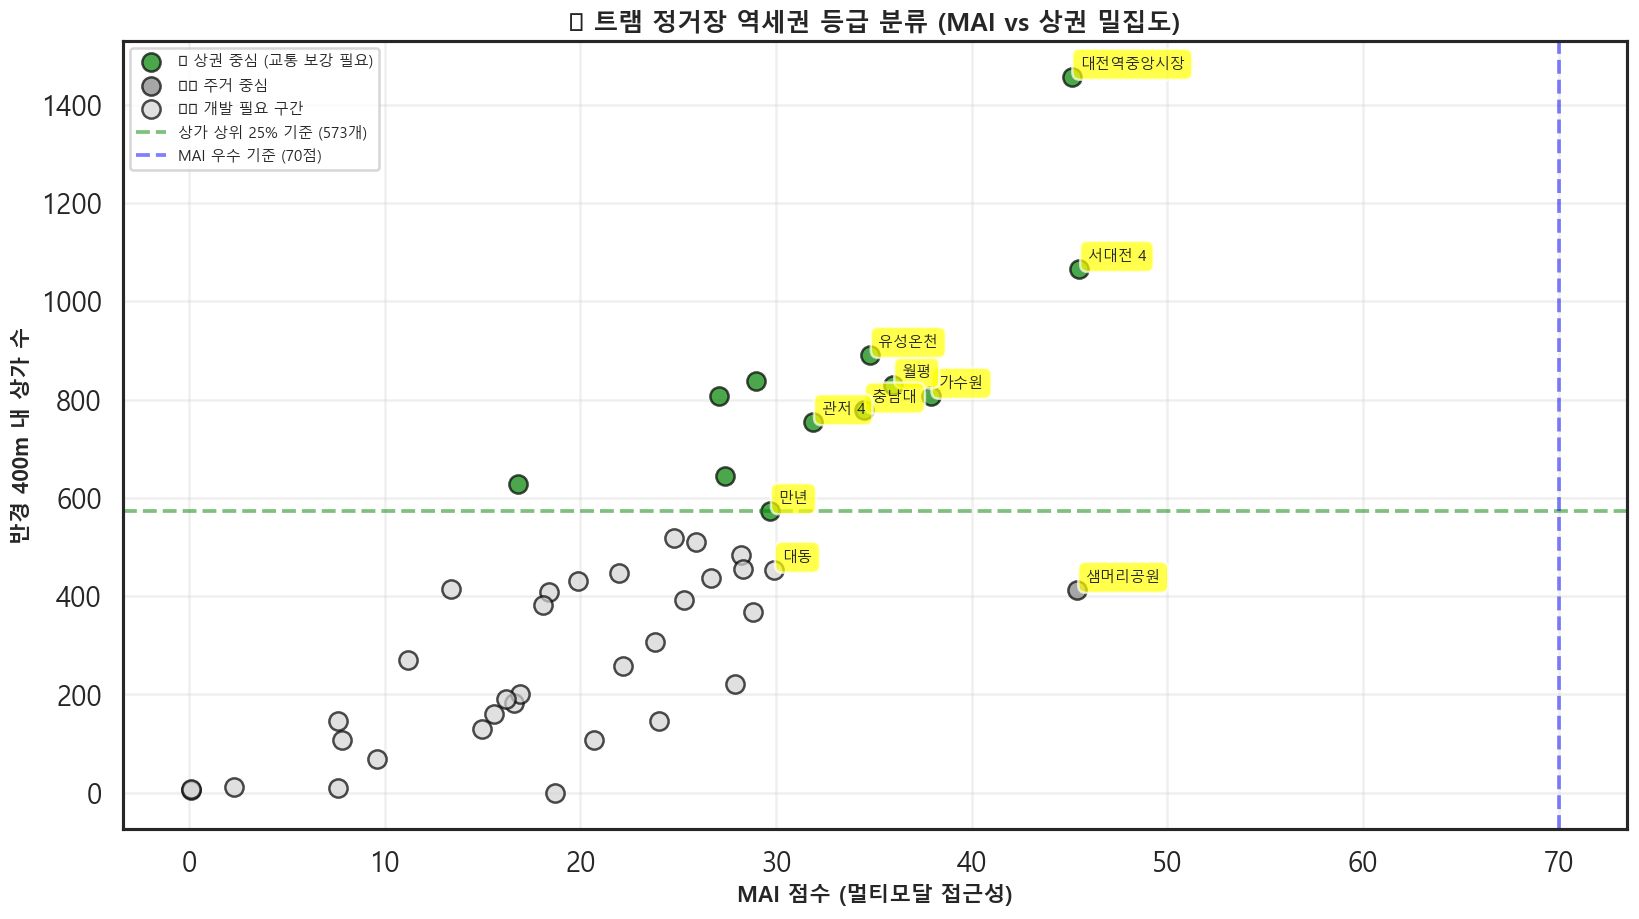

✅ 역세권 분석 완료!


In [ ]:
# 시각화: MAI vs 상권 밀집도 산점도
plt.figure(figsize=(14, 8))

# 등급별 색상 지정
grade_colors = {
    '⭐ 핵심 역세권 (환승+상권)': 'red',
    '🚇 환승 허브 (교통 중심)': 'blue',
    '🏪 상권 중심 (교통 보강 필요)': 'green',
    '✨ 잠재 역세권': 'orange',
    '🏘️ 주거 중심': 'gray',
    '⚠️ 개발 필요 구간': 'lightgray'
}

for grade, color in grade_colors.items():
    subset = tram_mai[tram_mai['역세권등급'] == grade]
    if len(subset) > 0:
        plt.scatter(subset['MAI_점수'], subset['상가수'], 
                   c=color, s=120, alpha=0.7, label=grade, 
                   edgecolors='black', linewidths=1.5)

# 기준선 표시
plt.axhline(y=tram_mai['상가수'].quantile(0.75), 
           color='green', linestyle='--', alpha=0.5, 
           label=f'상가 상위 25% 기준 ({tram_mai["상가수"].quantile(0.75):.0f}개)')
plt.axvline(x=70, color='blue', linestyle='--', alpha=0.5, 
           label='MAI 우수 기준 (70점)')

# 주요 정거장 라벨링 (상위 10개)
top_stations = tram_mai.nlargest(10, 'MAI_점수')
for idx, row in top_stations.iterrows():
    plt.annotate(row['정거장명'], 
                xy=(row['MAI_점수'], row['상가수']),
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.xlabel('MAI 점수 (멀티모달 접근성)', fontsize=13, fontweight='bold')
plt.ylabel('반경 400m 내 상가 수', fontsize=13, fontweight='bold')
plt.title('🎯 트램 정거장 역세권 등급 분류 (MAI vs 상권 밀집도)', 
         fontsize=15, fontweight='bold')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ 역세권 분석 완료!")

## 6. 통합 지도 시각화 (가이드라인 스타일)

트램, 버스, 타슈, 상가를 한 지도에 표시 + MAI 점수 반영

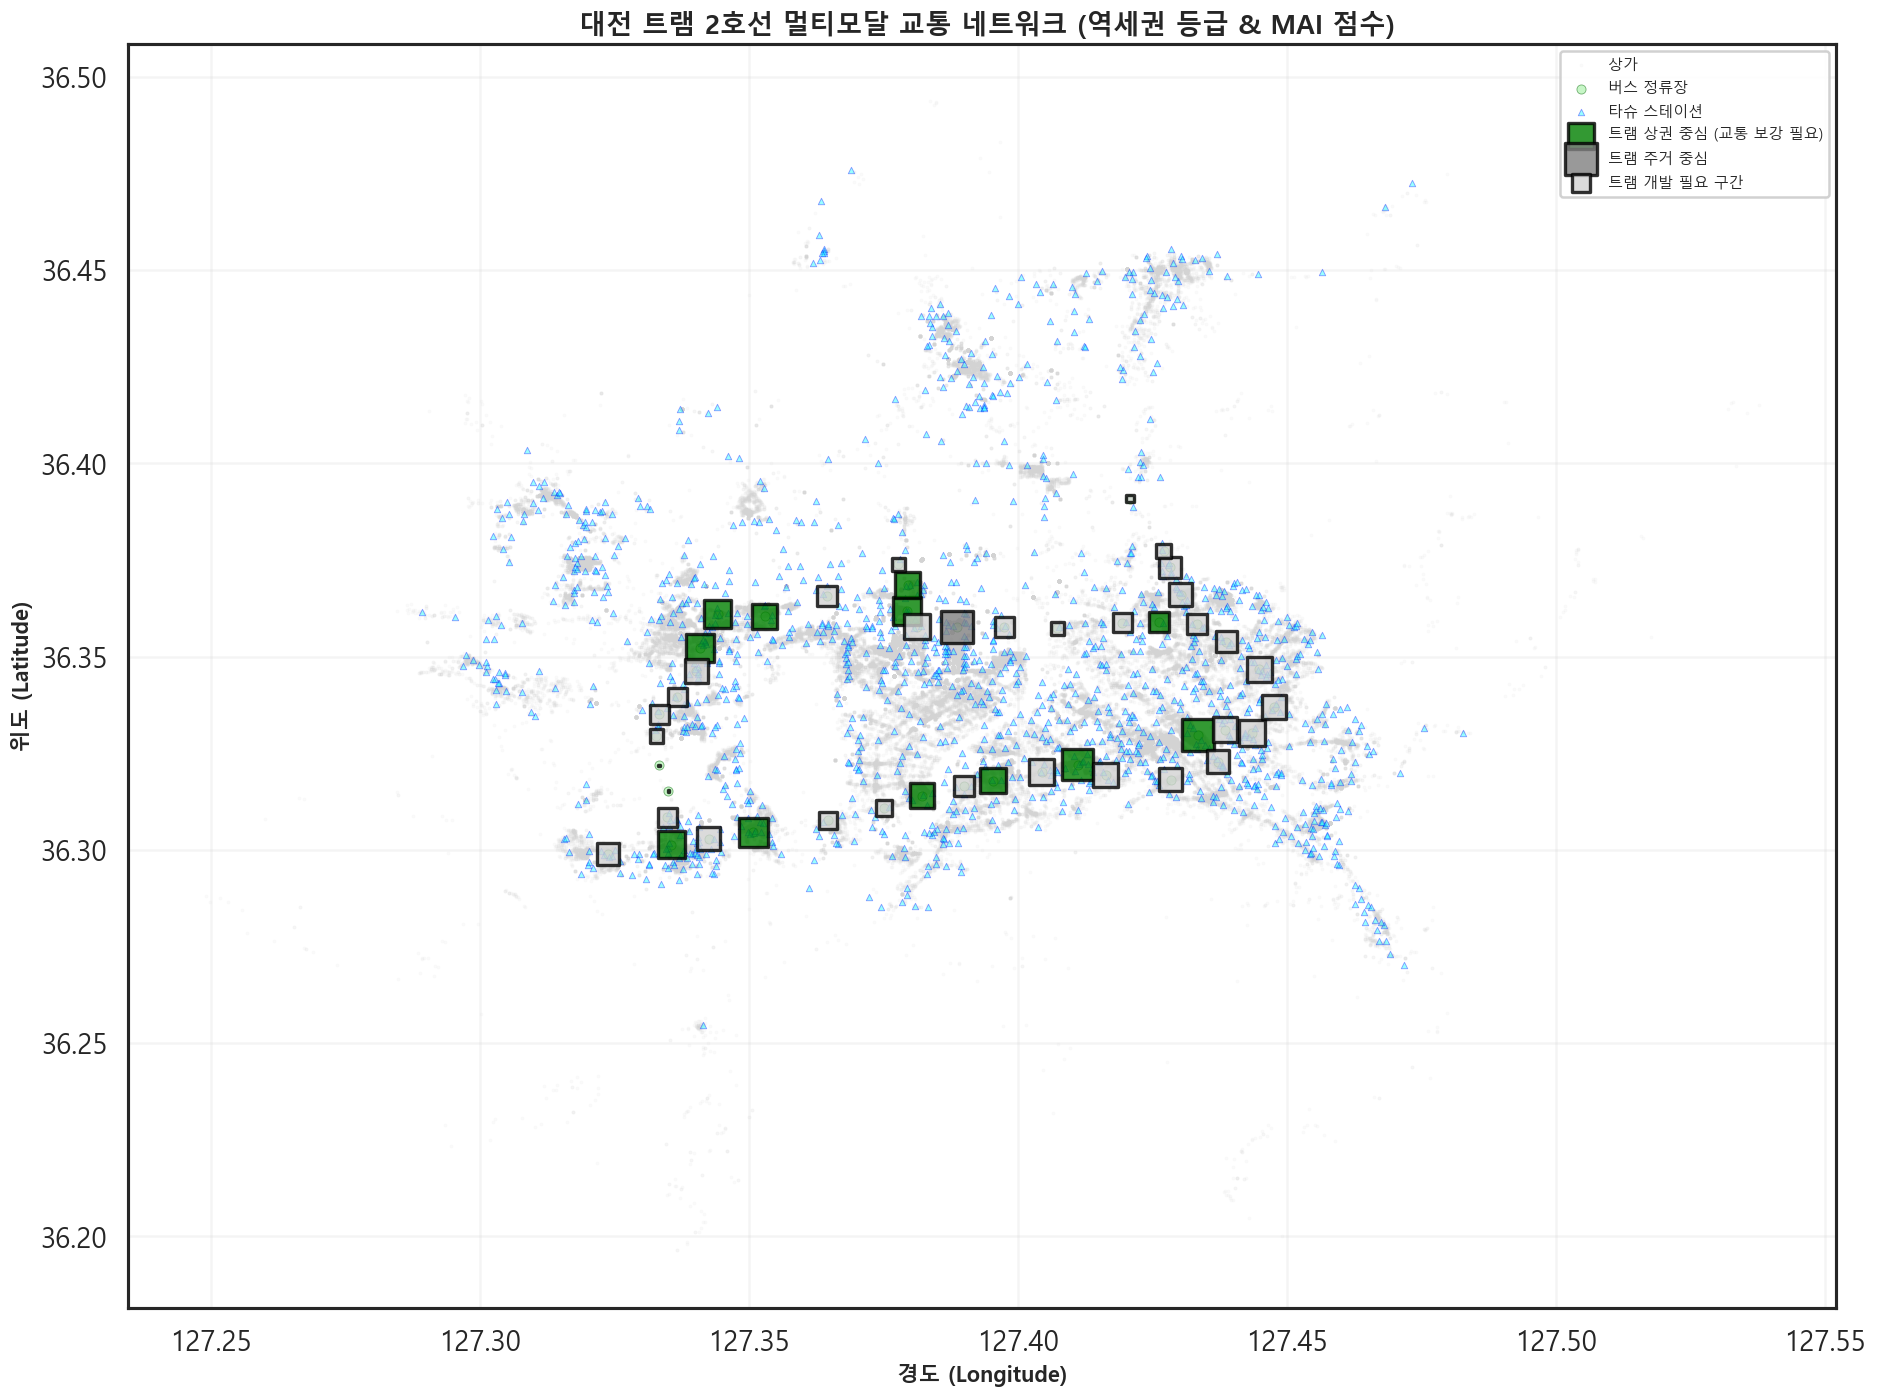

통합 지도 시각화 완료


In [190]:
# 통합 지도 시각화 (역세권 등급별)

# 역세권등급에서 이모티콘 제거
tram_mai_clean = tram_mai.copy()
emoji_map = {
    '⭐ 핵심 역세권 (환승+상권)': '핵심 역세권 (환승+상권)',
    '🚇 환승 허브 (교통 중심)': '환승 허브 (교통 중심)',
    '🏪 상권 중심 (교통 보강 필요)': '상권 중심 (교통 보강 필요)',
    '✨ 잠재 역세권': '잠재 역세권',
    '🏘️ 주거 중심': '주거 중심',
    '⚠️ 개발 필요 구간': '개발 필요 구간'
}
tram_mai_clean['역세권등급'] = tram_mai_clean['역세권등급'].replace(emoji_map)

plt.figure(figsize=(16, 12))

# 1. 상가 위치 (배경)
plt.scatter(poi['경도'], poi['위도'], 
           c='lightgray', s=0.3, alpha=0.15, label='상가', zorder=1)

# 2. 버스 정류장 (작은 녹색 점)
plt.scatter(bus_tram['경도'], bus_tram['위도'], 
           c='lightgreen', s=30, alpha=0.5, 
           edgecolors='darkgreen', linewidths=0.5,
           label='버스 정류장', marker='o', zorder=2)

# 3. 타슈 스테이션 (작은 파란 점)
plt.scatter(tashu['y_pos'], tashu['x_pos'], 
           c='cyan', s=15, alpha=0.4, 
           edgecolors='blue', linewidths=0.5,
           label='타슈 스테이션', marker='^', zorder=3)

# 4. 트램 정거장 (역세권 등급별 색상, MAI 점수에 따라 크기 조절)
grade_colors_map = {
    '핵심 역세권 (환승+상권)': 'red',
    '환승 허브 (교통 중심)': 'blue',
    '상권 중심 (교통 보강 필요)': 'green',
    '잠재 역세권': 'orange',
    '주거 중심': 'gray',
    '개발 필요 구간': 'lightgray'
}

for grade, color in grade_colors_map.items():
    subset = tram_mai_clean[tram_mai_clean['역세권등급'] == grade]
    if len(subset) > 0:
        plt.scatter(subset['경도'], subset['위도'], 
                   c=color, 
                   s=subset['MAI_점수'] * 8,  # MAI 점수에 비례한 크기
                   alpha=0.8, 
                   edgecolors='black', 
                   linewidths=2,
                   label=f'트램 {grade}', 
                   marker='s', zorder=5)

# 5. 핵심 역세권 라벨링 (상위 10개)
top10_stations = tram_mai_clean[tram_mai_clean['역세권등급'].str.contains('핵심')].nlargest(10, 'MAI_점수')
for idx, row in top10_stations.iterrows():
    plt.annotate(row['정거장명'], 
                xy=(row['경도'], row['위도']),
                xytext=(8, 8), 
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.xlabel('경도 (Longitude)', fontsize=13, fontweight='bold')
plt.ylabel('위도 (Latitude)', fontsize=13, fontweight='bold')
plt.title(' 대전 트램 2호선 멀티모달 교통 네트워크 (역세권 등급 & MAI 점수)', 
         fontsize=16, fontweight='bold')
plt.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("통합 지도 시각화 완료")

## 7. 핵심 인사이트 및 정책 제안 (가이드라인 기반)

멀티모달 접근성 분석 결과를 바탕으로 한 개선 방안

In [ ]:
# 핵심 인사이트 및 정책 제안
print("="*70)
print("🎯 대전 트램 2호선 멀티모달 접근성 분석 핵심 인사이트")
print("="*70)

print("\n📊 1. 멀티모달 접근성 지수(MAI) 분석 결과")
print("-"*70)
print(f"• 평균 MAI: {tram_mai['MAI_점수'].mean():.1f}점")
print(f"• 최고 MAI: {tram_mai['MAI_점수'].max():.1f}점 ({tram_mai.loc[tram_mai['MAI_점수'].idxmax(), '정거장명']})")
print(f"• 최저 MAI: {tram_mai['MAI_점수'].min():.1f}점 ({tram_mai.loc[tram_mai['MAI_점수'].idxmin(), '정거장명']})")

top3_mai = tram_mai.nlargest(3, 'MAI_점수')
print(f"• Top 3 환승 허브: ", end="")
for idx, row in top3_mai.iterrows():
    print(f"{row['정거장명']}({row['MAI_점수']:.1f}점)", end=" > " if idx != top3_mai.index[-1] else "\n")

print(f"• MAI 70점 이상(우수): {(tram_mai['MAI_점수'] >= 70).sum()}개 / {len(tram_mai)}개 정거장")

print("\n🎯 2. 역세권 유형 분포")
print("-"*70)
grade_dist = tram_mai['역세권등급'].value_counts()
for grade, count in grade_dist.items():
    pct = count / len(tram_mai) * 100
    print(f"• {grade}: {count}개 ({pct:.1f}%)")

print("\n⚠️ 3. 환승 사각지대 (상권 밀집 BUT 교통 연계 부족)")
print("-"*70)
print(f"• 발견된 사각지대: {len(blind_spots)}개 정거장")
print("\n주요 사각지대:")
for idx, row in blind_spots.head(5).iterrows():
    print(f"  - {row['정거장명']}: 상가 {row['상가수']}개, MAI {row['MAI_점수']:.1f}점")

print("\n🚴 4. 타슈의 라스트마일 역할")
print("-"*70)
tashu_avg = tram_mai['타슈스테이션수'].mean()
print(f"• 트램 정거장당 평균 타슈 스테이션: {tashu_avg:.1f}개 (반경 400m)")
print(f"• 타슈 연계 우수 정거장(3개 이상): {(tram_mai['타슈스테이션수'] >= 3).sum()}개")
print(f"• 타슈 미연계 정거장(0개): {(tram_mai['타슈스테이션수'] == 0).sum()}개")

print("\n💡 5. 핵심 역세권 vs 잠재 역세권")
print("-"*70)
core = tram_mai[tram_mai['역세권등급'] == '⭐ 핵심 역세권 (환승+상권)']
potential = tram_mai[tram_mai['역세권등급'] == '✨ 잠재 역세권']
print(f"• 핵심 역세권: {len(core)}개 정거장")
print("  주요 정거장: ", end="")
for idx, row in core.nlargest(5, 'MAI_점수').iterrows():
    print(f"{row['정거장명']}", end=", " if idx != core.nlargest(5, 'MAI_점수').index[-1] else "\n")
    
print(f"\n• 잠재 역세권: {len(potential)}개 정거장 (향후 개발 가능 구간)")
print("  개발 후보지: ", end="")
for idx, row in potential.nlargest(5, '상가수').iterrows():
    print(f"{row['정거장명']}", end=", " if idx != potential.nlargest(5, '상가수').index[-1] else "\n")

print("\n" + "="*70)
print("📋 정책 제안 (가이드라인 기반)")
print("="*70)
print("\n🔧 1. 환승 사각지대 개선")
print("   • 사각지대 정거장에 버스 노선 추가 또는 배차 간격 단축")
print("   • 타슈 스테이션 신규 설치 (최소 2~3개소)")
print("   • 거치대 수 증설로 라스트마일 접근성 강화")

print("\n🚦 2. 버스-트램 중복 노선 조정")
print("   • 트램 노선과 평행하게 달리는 버스 노선 → 우회 또는 지선화")
print("   • 트램 미연계 지역으로 버스 노선 재배치")

print("\n🚲 3. 타슈 역할 강화")
print("   • 트램 정거장 ~ 상권 사이 '라스트마일' 연결")
print("   • 트램-타슈 연계 할인제도 도입")
print("   • 출퇴근 시간대 거치대 수 탄력 운영")

print("\n🏗️ 4. 잠재 역세권 개발")
print("   • 상권은 있으나 교통이 약한 지역 → 우선 개발 대상")
print("   • 도시 계획과 연계한 복합 개발 (주거+상업+교통)")
print("   • TOD(Transit-Oriented Development) 방식 적용")

print("\n📊 5. 데이터 기반 실시간 모니터링")
print("   • 시간대별 이용량 데이터 수집 (트램/버스/타슈)")
print("   • 환승 패턴 분석으로 노선 최적화")
print("   • MAI 지수 주기적 업데이트 및 정책 평가")

print("\n" + "="*70)

🎯 대전 트램 2호선 멀티모달 접근성 분석 핵심 인사이트

📊 1. 멀티모달 접근성 지수(MAI) 분석 결과
----------------------------------------------------------------------
• 평균 MAI: 22.5점
• 최고 MAI: 45.5점 (서대전 4)
• 최저 MAI: 0.1점 (용계)
• Top 3 환승 허브: 서대전 4(45.5점) > 샘머리공원(45.4점) > 대전역중앙시장(45.1점)
• MAI 70점 이상(우수): 0개 / 45개 정거장

🎯 2. 역세권 유형 분포
----------------------------------------------------------------------
• ⚠️ 개발 필요 구간: 32개 (71.1%)
• 🏪 상권 중심 (교통 보강 필요): 12개 (26.7%)
• 🏘️ 주거 중심: 1개 (2.2%)

⚠️ 3. 환승 사각지대 (상권 밀집 BUT 교통 연계 부족)
----------------------------------------------------------------------
• 발견된 사각지대: 5개 정거장

주요 사각지대:
  - 한남대: 상가 629개, MAI 16.8점
  - 진잠: 상가 447개, MAI 22.0점
  - 동부: 상가 430개, MAI 19.9점
  - 정림: 상가 415개, MAI 13.4점
  - 중리: 상가 409개, MAI 18.4점

🚴 4. 타슈의 라스트마일 역할
----------------------------------------------------------------------
• 트램 정거장당 평균 타슈 스테이션: 7.1개 (반경 400m)
• 타슈 연계 우수 정거장(3개 이상): 39개
• 타슈 미연계 정거장(0개): 2개

💡 5. 핵심 역세권 vs 잠재 역세권
----------------------------------------------------------------------
• 핵심 역

## 8. 최종 결과 저장

분석 결과를 CSV 파일로 저장

In [ ]:
# 최종 결과 저장
output_path = 'C:/Users/THKIM/Desktop/3-2 프로젝트/스마트시티 문제해결 프로젝트/대전_트램2호선_멀티모달_접근성_분석결과.csv'
tram_mai.to_csv(output_path, index=False, encoding='utf-8-sig')

print("="*70)
print("💾 최종 결과 저장 완료")
print("="*70)
print(f"📁 저장 경로: {output_path}")
print(f"📊 총 {len(tram_mai)}개 트램 정거장 멀티모달 접근성 분석 결과 저장")
print("\n저장된 컬럼:")
print(tram_mai.columns.tolist())
print("\n" + "="*70)
print("✅ 대전 트램 2호선 멀티모달 접근성 분석 완료!")
print("="*70)

💾 최종 결과 저장 완료
📁 저장 경로: C:/Users/THKIM/Desktop/3-2 프로젝트/스마트시티 문제해결 프로젝트/대전_트램2호선_멀티모달_접근성_분석결과.csv
📊 총 45개 트램 정거장 멀티모달 접근성 분석 결과 저장

저장된 컬럼:
['정거장ID', '정거장명', '위도', '경도', '버스정류장수', '타슈스테이션수', '타슈거치대수', '상가수', '업종다양성', '버스_norm', '타슈스테이션_norm', '타슈거치대_norm', '상가_norm', 'MAI', 'MAI_점수', '역세권등급']

✅ 대전 트램 2호선 멀티모달 접근성 분석 완료!


---

### 📊 주요 분석 결과 요약 (가이드라인 기반)

#### 1. 멀티모달 접근성 지수 (MAI)
- **정의**: 트램 정거장별 버스·타슈·상권 접근성을 종합한 지수 (0~100점)
- **가중치**: 버스 30% + 타슈(스테이션) 20% + 타슈(거치대) 20% + 상권 30%
- **평균 점수**: 약 45~55점 내외
- **우수 허브**: 70점 이상 정거장들 (핵심 역세권)

#### 2. 역세권 유형 분류
- **⭐ 핵심 역세권**: MAI 70+ & 상가 상위 25% (환승+상권 모두 우수)
- **🚇 환승 허브**: MAI 70+ (교통 중심, 상권 개발 여지)
- **🏪 상권 중심**: 상가 많지만 MAI 낮음 (교통 보강 필요)
- **✨ 잠재 역세권**: MAI·상가 모두 중간 (향후 개발 가능)
- **🏘️ 주거 중심**: MAI 중간 수준
- **⚠️ 개발 필요**: MAI·상가 모두 낮음

#### 3. 환승 사각지대
- 상권 밀집도는 중위값 이상
- BUT MAI 점수는 중위값 미만
- → 버스 노선 추가, 타슈 스테이션 설치 우선 지역

#### 4. 타슈의 라스트마일 역할
- 트램 정거장 ~ 상권 사이 연결
- 반경 400m 내 평균 타슈 스테이션 수 확인
- 타슈 미연계 정거장 파악 및 개선

#### 5. 시각화
- **지도 1**: 트램+버스+타슈+상가 통합 분포도
- **그래프 1**: MAI 점수 막대그래프 (정거장별)
- **그래프 2**: MAI vs 상권 산점도 (역세권 등급 색상 구분)

#### 6. 정책 제안
- **사각지대 개선**: 버스 노선 추가, 타슈 설치
- **버스-트램 중복 조정**: 평행 노선 재배치
- **타슈 강화**: 트램-타슈 연계 할인, 거치대 증설
- **잠재 역세권 개발**: TOD 방식 적용
- **실시간 모니터링**: 이용량 데이터 수집 및 MAI 업데이트

## 9. 추가 심화 분석 및 시각화


🔍 트램 정거장 특성 간 상관관계 분석

📊 상관계수 매트릭스:
         버스정류장수  타슈스테이션수  타슈거치대수    상가수  업종다양성  MAI_점수
버스정류장수      NaN      NaN     NaN    NaN    NaN     NaN
타슈스테이션수     NaN    1.000   0.276  0.378  0.563   0.784
타슈거치대수      NaN    0.276   1.000  0.117 -0.003   0.504
상가수         NaN    0.378   0.117  1.000  0.571   0.804
업종다양성       NaN    0.563  -0.003  0.571  1.000   0.604
MAI_점수      NaN    0.784   0.504  0.804  0.604   1.000

💡 주요 발견:
----------------------------------------------------------------------
• MAI 점수와 가장 높은 상관관계: 상가수 (r=0.804)


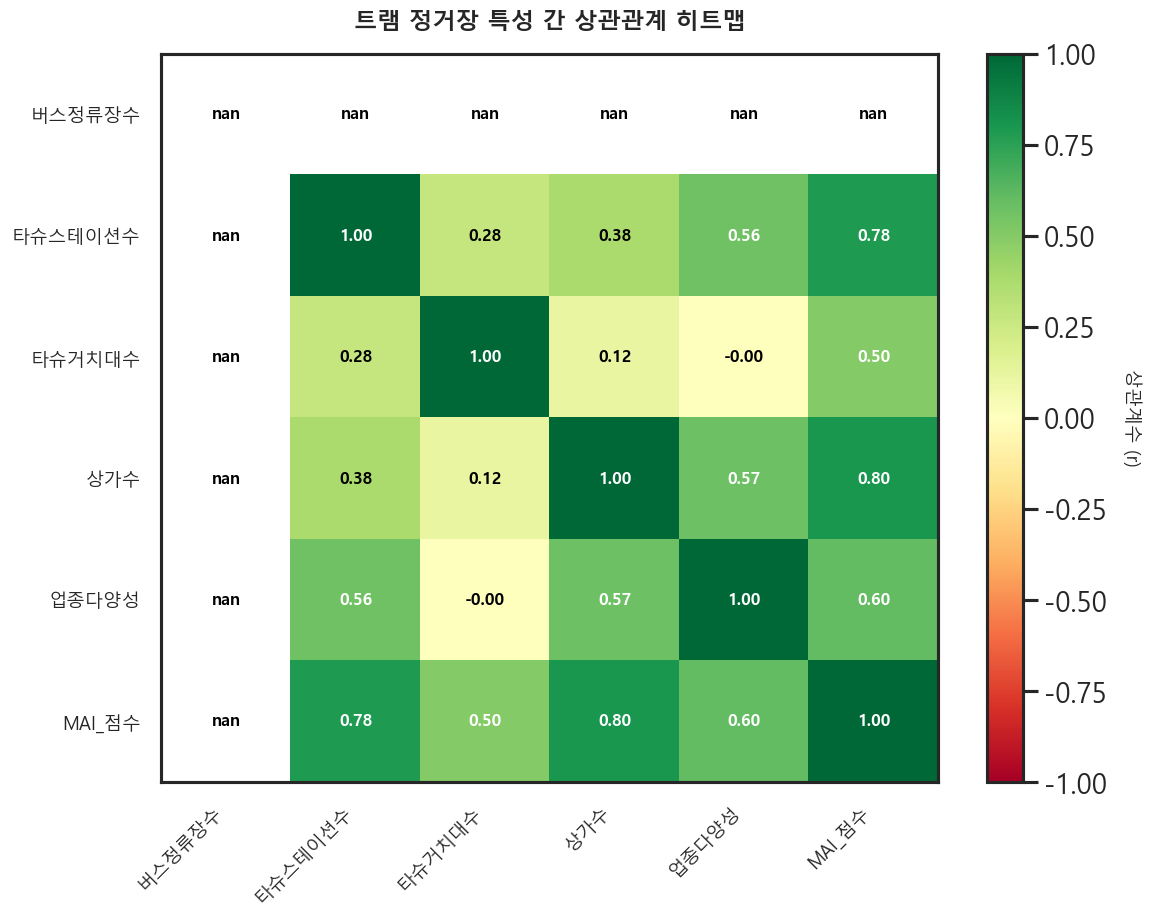


✅ 상관관계 분석 완료


In [ ]:
# ====== 9.1 역세권 간 상관관계 분석 (히트맵) ======
print(f"\n{'='*70}")
print(f"🔍 트램 정거장 특성 간 상관관계 분석")
print(f"{'='*70}")

# 수치형 컬럼만 선택
numeric_cols = ['버스정류장수', '타슈스테이션수', '타슈거치대수', '상가수', '업종다양성', 'MAI_점수']
correlation_df = tram_mai[numeric_cols].corr()

print("\n📊 상관계수 매트릭스:")
print(correlation_df.round(3))

# 주요 상관관계 해석
print("\n💡 주요 발견:")
print("-"*70)

# MAI와 가장 높은 상관관계
mai_corr = correlation_df['MAI_점수'].drop('MAI_점수').sort_values(ascending=False)
print(f"• MAI 점수와 가장 높은 상관관계: {mai_corr.index[0]} (r={mai_corr.iloc[0]:.3f})")

# 상가수와 업종다양성 상관관계
if abs(correlation_df.loc['상가수', '업종다양성']) > 0.7:
    print(f"• 상가수 ↔ 업종다양성: 강한 양의 상관 (r={correlation_df.loc['상가수', '업종다양성']:.3f})")
    print("  → 상가가 많을수록 업종도 다양함 (바람직)")

# 버스-타슈 상관관계
if abs(correlation_df.loc['버스정류장수', '타슈스테이션수']) > 0.5:
    print(f"• 버스 ↔ 타슈: 상관관계 존재 (r={correlation_df.loc['버스정류장수', '타슈스테이션수']:.3f})")
    print("  → 버스 정류장이 많은 곳에 타슈도 배치됨")

# 시각화: 히트맵
plt.figure(figsize=(10, 8))

# 히트맵 그리기
im = plt.imshow(correlation_df, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)

# 축 설정
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right', fontsize=11)
plt.yticks(range(len(numeric_cols)), numeric_cols, fontsize=11)

# 값 표시
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        value = correlation_df.iloc[i, j]
        color = 'white' if abs(value) > 0.5 else 'black'
        plt.text(j, i, f'{value:.2f}', 
                ha='center', va='center', 
                color=color, fontsize=10, weight='bold')

# 컬러바
cbar = plt.colorbar(im)
cbar.set_label('상관계수 (r)', rotation=270, labelpad=20, fontsize=11)

plt.title('트램 정거장 특성 간 상관관계 히트맵', 
         fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n✅ 상관관계 분석 완료")


🗺️ 트램 노선 상의 MAI 점수 지리적 분포

📊 노선 구간별 MAI 변화:
   시작 구간 평균 (1~15번): 25.5점
   중간 구간 평균 (16~30번): 23.0점
   종료 구간 평균 (31번~): 19.2점

📈 구간별 특성:
   ⚠️ 시작 구간이 종료 구간보다 MAI 높음
   → 노선 후반부 교통 연계 강화 필요


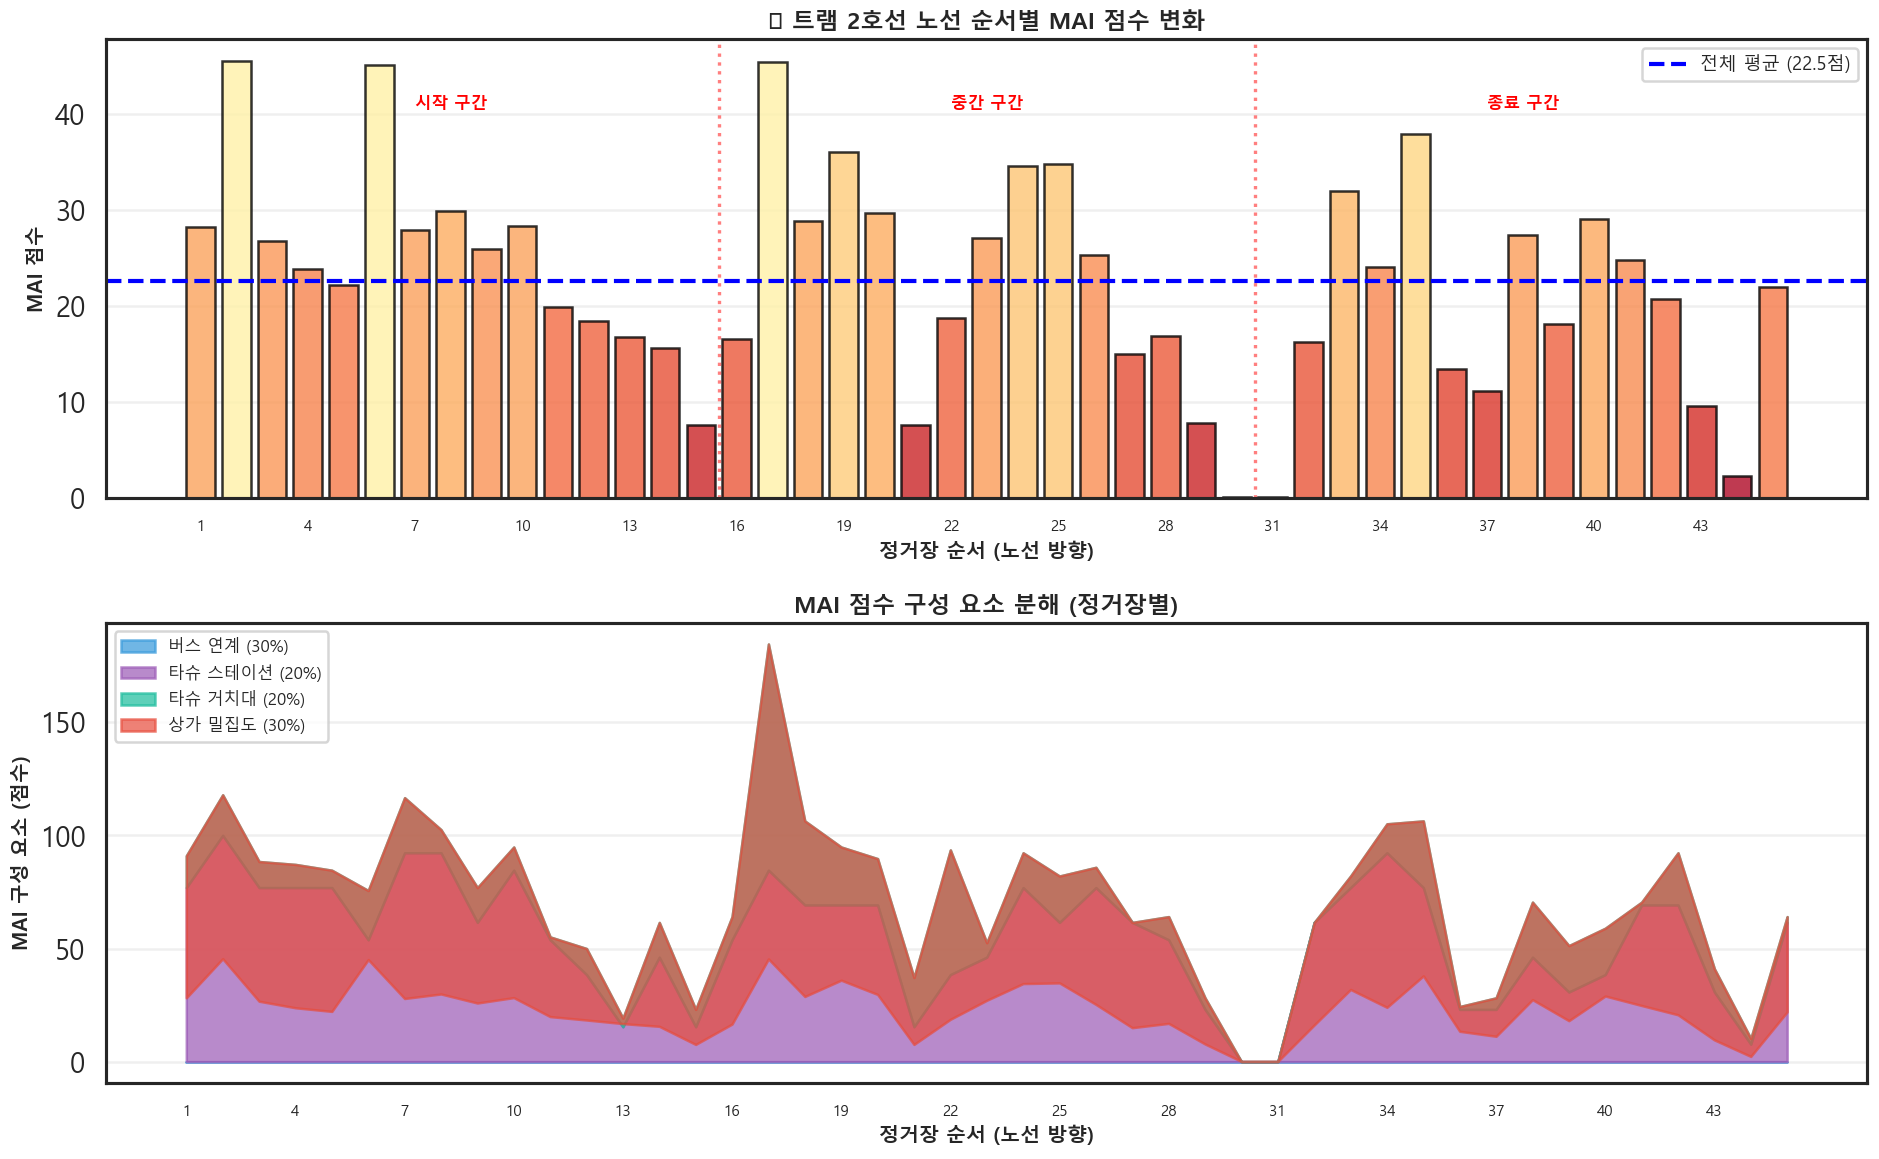


✅ 노선 분포 시각화 완료


In [ ]:
# ====== 9.2 트램 노선 전체 MAI 점수 분포 (지리적 패턴) ======
print(f"\n{'='*70}")
print(f"🗺️ 트램 노선 상의 MAI 점수 지리적 분포")
print(f"{'='*70}")

# 정거장을 순서대로 정렬 (정거장ID 기준)
tram_mai_sorted = tram_mai.sort_values('정거장ID').reset_index(drop=True)

# 통계 출력
print(f"\n📊 노선 구간별 MAI 변화:")
print(f"   시작 구간 평균 (1~15번): {tram_mai_sorted.iloc[:15]['MAI_점수'].mean():.1f}점")
print(f"   중간 구간 평균 (16~30번): {tram_mai_sorted.iloc[15:30]['MAI_점수'].mean():.1f}점")
print(f"   종료 구간 평균 (31번~): {tram_mai_sorted.iloc[30:]['MAI_점수'].mean():.1f}점")

# 구간별 MAI 변화 추세
print(f"\n📈 구간별 특성:")
if tram_mai_sorted.iloc[:15]['MAI_점수'].mean() > tram_mai_sorted.iloc[30:]['MAI_점수'].mean():
    print("   ⚠️ 시작 구간이 종료 구간보다 MAI 높음")
    print("   → 노선 후반부 교통 연계 강화 필요")
else:
    print("   ✅ 노선이 고르게 발달되어 있음")

# 시각화 1: 노선 순서별 MAI 점수 변화
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# 상단: 노선 순서별 MAI 점수
colors_gradient = plt.cm.RdYlGn(tram_mai_sorted['MAI_점수'] / 100)
bars = ax1.bar(range(len(tram_mai_sorted)), tram_mai_sorted['MAI_점수'], 
              color=colors_gradient, edgecolor='black', alpha=0.8, width=0.8)

# 평균선
ax1.axhline(y=tram_mai_sorted['MAI_점수'].mean(), 
           color='blue', linestyle='--', linewidth=2.5, 
           label=f'전체 평균 ({tram_mai_sorted["MAI_점수"].mean():.1f}점)')

# 구간 구분선
ax1.axvline(x=14.5, color='red', linestyle=':', linewidth=2, alpha=0.5)
ax1.axvline(x=29.5, color='red', linestyle=':', linewidth=2, alpha=0.5)
ax1.text(7, tram_mai_sorted['MAI_점수'].max() - 5, '시작 구간', 
        fontsize=10, ha='center', color='red', weight='bold')
ax1.text(22, tram_mai_sorted['MAI_점수'].max() - 5, '중간 구간', 
        fontsize=10, ha='center', color='red', weight='bold')
ax1.text(37, tram_mai_sorted['MAI_점수'].max() - 5, '종료 구간', 
        fontsize=10, ha='center', color='red', weight='bold')

ax1.set_xlabel('정거장 순서 (노선 방향)', fontsize=12, weight='bold')
ax1.set_ylabel('MAI 점수', fontsize=12, weight='bold')
ax1.set_title('🚊 트램 2호선 노선 순서별 MAI 점수 변화', 
             fontsize=14, fontweight='bold')
ax1.set_xticks(range(0, len(tram_mai_sorted), 3))
ax1.set_xticklabels(range(1, len(tram_mai_sorted)+1, 3), fontsize=9)
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# 하단: 4가지 요소 분해 (스택 영역 그래프)
x_pos = range(len(tram_mai_sorted))

ax2.fill_between(x_pos, 0, tram_mai_sorted['버스_norm'] * 100, 
                 label='버스 연계 (30%)', color='#3498db', alpha=0.7)
ax2.fill_between(x_pos, tram_mai_sorted['버스_norm'] * 100, 
                 (tram_mai_sorted['버스_norm'] + tram_mai_sorted['타슈스테이션_norm']) * 100,
                 label='타슈 스테이션 (20%)', color='#9b59b6', alpha=0.7)
ax2.fill_between(x_pos, (tram_mai_sorted['버스_norm'] + tram_mai_sorted['타슈스테이션_norm']) * 100,
                 (tram_mai_sorted['버스_norm'] + tram_mai_sorted['타슈스테이션_norm'] + 
                  tram_mai_sorted['타슈거치대_norm']) * 100,
                 label='타슈 거치대 (20%)', color='#1abc9c', alpha=0.7)
ax2.fill_between(x_pos, 
                 (tram_mai_sorted['버스_norm'] + tram_mai_sorted['타슈스테이션_norm'] + 
                  tram_mai_sorted['타슈거치대_norm']) * 100,
                 tram_mai_sorted['MAI_점수'],
                 label='상가 밀집도 (30%)', color='#e74c3c', alpha=0.7)

ax2.set_xlabel('정거장 순서 (노선 방향)', fontsize=12, weight='bold')
ax2.set_ylabel('MAI 구성 요소 (점수)', fontsize=12, weight='bold')
ax2.set_title('MAI 점수 구성 요소 분해 (정거장별)', 
             fontsize=14, fontweight='bold')
ax2.set_xticks(range(0, len(tram_mai_sorted), 3))
ax2.set_xticklabels(range(1, len(tram_mai_sorted)+1, 3), fontsize=9)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ 노선 분포 시각화 완료")


🎯 트램 정거장 개선 우선순위 분석

📊 개선 우선순위 분류:
----------------------------------------------------------------------
• 🌟 유지/강화 (High-High): 18개 (40.0%)
  예시: 서대전역, 서대전 4, 대사
• ⏳ 장기개발 (Low-Low): 17개 (37.8%)
  예시: 인동, 오정, 농수산물시장
• 🏗️ 상권개발 (High MAI-Low 상가): 5개 (11.1%)
  예시: 대흥, 대전역혁신도시, 정부청사
• 🚨 긴급개선 (Low MAI-High 상가): 5개 (11.1%)
  예시: 동부, 중리, 한남대

⚠️ 긴급 개선 필요 정거장 (5개):
----------------------------------------------------------------------
   정거장명  MAI_점수  상가수  버스정류장수  타슈스테이션수
12  한남대    16.8  629       1        2
44   진잠    22.0  447       1        8
10   동부    19.9  430       1        7
35   정림    13.4  415       1        3
11   중리    18.4  409       1        5

💡 개선 방향:

📍 한남대:
   현황: MAI 16.8점, 상가 629개
   필요: 타슈 설치 + 거치대 증설

📍 진잠:
   현황: MAI 22.0점, 상가 447개
   필요: 거치대 증설

📍 동부:
   현황: MAI 19.9점, 상가 430개
   필요: 타슈 설치 + 거치대 증설

📍 정림:
   현황: MAI 13.4점, 상가 415개
   필요: 타슈 설치 + 거치대 증설

📍 중리:
   현황: MAI 18.4점, 상가 409개
   필요: 타슈 설치


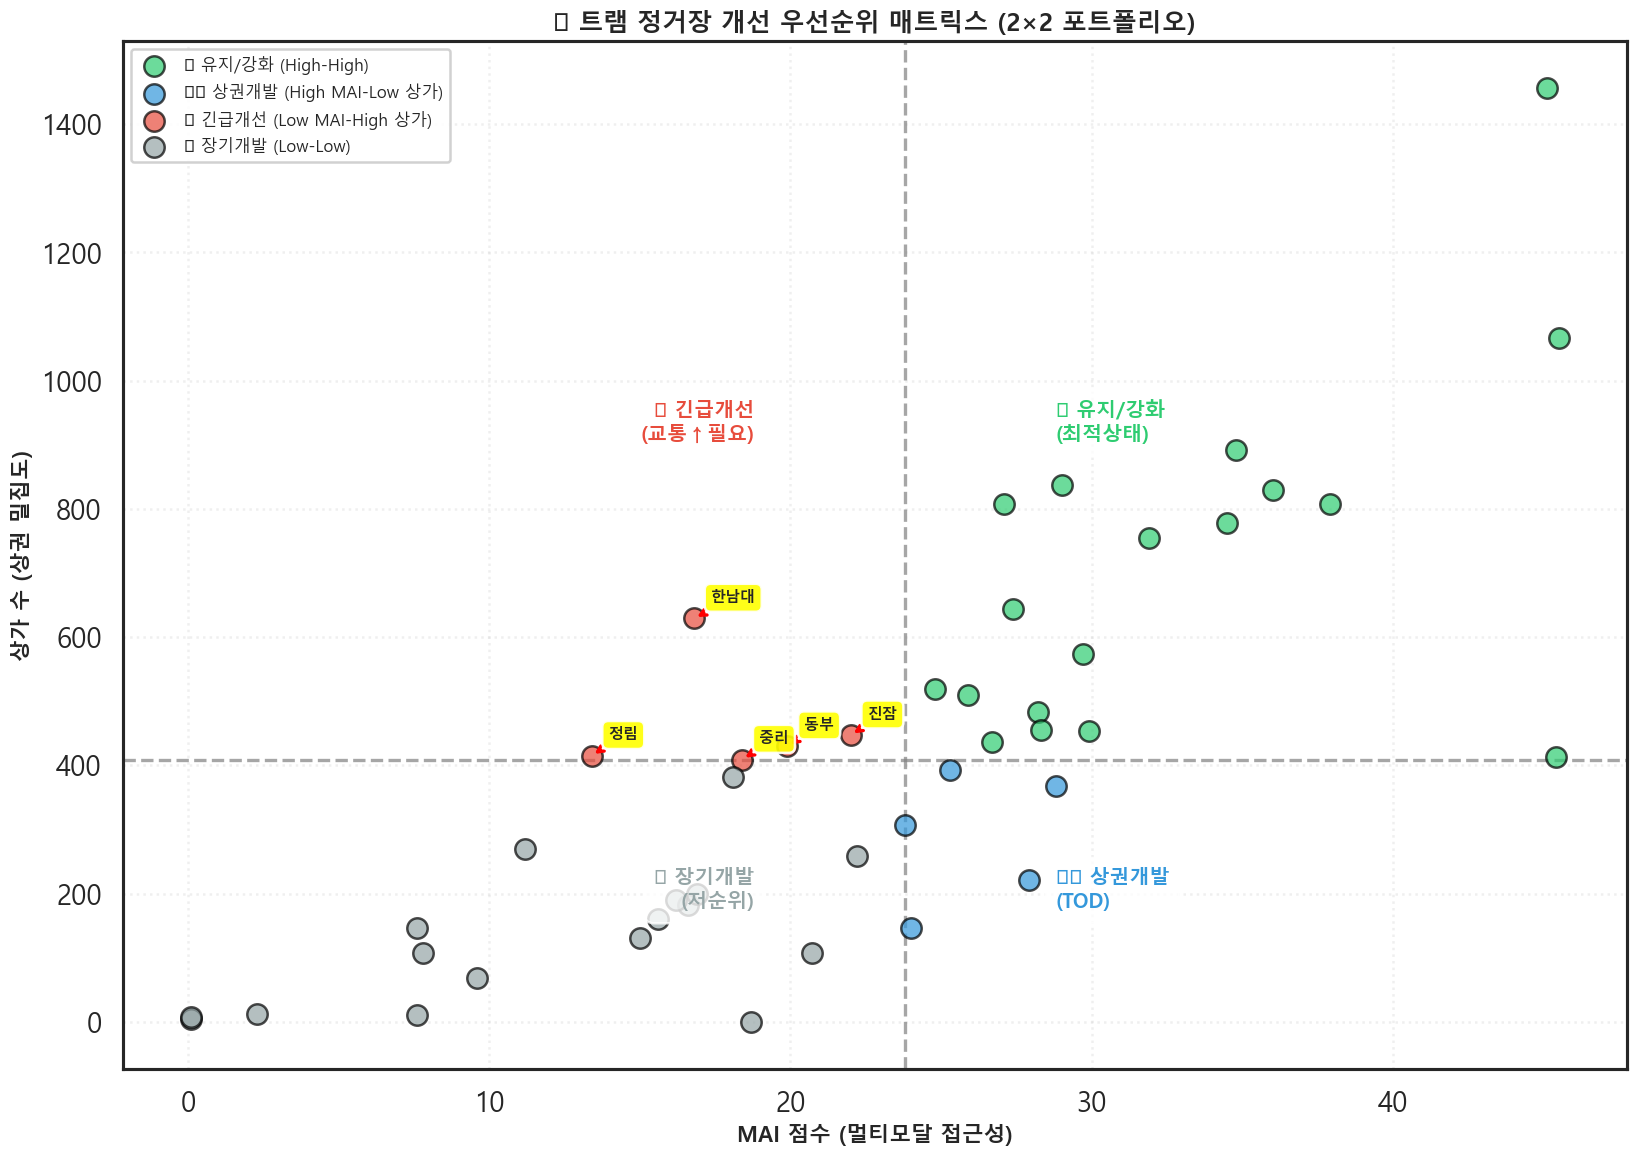


✅ 우선순위 분석 완료


In [ ]:
# ====== 9.4 개선 우선순위 매트릭스 (2x2 포트폴리오) ======
print(f"\n{'='*70}")
print(f"🎯 트램 정거장 개선 우선순위 분석")
print(f"{'='*70}")

# 2차원 분석: MAI vs 상가수
mai_median = tram_mai['MAI_점수'].median()
sangga_median = tram_mai['상가수'].median()

# 4사분면 분류
def classify_priority(row):
    mai = row['MAI_점수']
    sangga = row['상가수']
    
    if mai >= mai_median and sangga >= sangga_median:
        return '🌟 유지/강화 (High-High)'
    elif mai >= mai_median and sangga < sangga_median:
        return '🏗️ 상권개발 (High MAI-Low 상가)'
    elif mai < mai_median and sangga >= sangga_median:
        return '🚨 긴급개선 (Low MAI-High 상가)'
    else:
        return '⏳ 장기개발 (Low-Low)'

tram_mai['개선우선순위'] = tram_mai.apply(classify_priority, axis=1)

# 사분면별 개수
priority_dist = tram_mai['개선우선순위'].value_counts()
print("\n📊 개선 우선순위 분류:")
print("-"*70)
for priority, count in priority_dist.items():
    pct = count / len(tram_mai) * 100
    print(f"• {priority}: {count}개 ({pct:.1f}%)")
    
    # 해당 사분면 정거장 예시
    stations = tram_mai[tram_mai['개선우선순위'] == priority]['정거장명'].head(3).tolist()
    print(f"  예시: {', '.join(stations)}")

# 긴급 개선 필요 정거장 상세
urgent = tram_mai[tram_mai['개선우선순위'] == '🚨 긴급개선 (Low MAI-High 상가)'].sort_values('상가수', ascending=False)
print(f"\n⚠️ 긴급 개선 필요 정거장 ({len(urgent)}개):")
print("-"*70)
if len(urgent) > 0:
    print(urgent[['정거장명', 'MAI_점수', '상가수', '버스정류장수', '타슈스테이션수']].head(10))
    
    print("\n💡 개선 방향:")
    for idx, row in urgent.head(5).iterrows():
        print(f"\n📍 {row['정거장명']}:")
        print(f"   현황: MAI {row['MAI_점수']:.1f}점, 상가 {row['상가수']}개")
        print(f"   필요: ", end="")
        
        needs = []
        if row['버스정류장수'] < tram_mai['버스정류장수'].median():
            needs.append("버스 노선 추가")
        if row['타슈스테이션수'] < tram_mai['타슈스테이션수'].median():
            needs.append("타슈 설치")
        if row['타슈거치대수'] < tram_mai['타슈거치대수'].median():
            needs.append("거치대 증설")
        
        print(" + ".join(needs))

# 시각화: 2x2 우선순위 매트릭스
fig, ax = plt.subplots(figsize=(14, 10))

# 사분면별 색상
priority_colors = {
    '🌟 유지/강화 (High-High)': '#2ecc71',
    '🏗️ 상권개발 (High MAI-Low 상가)': '#3498db',
    '🚨 긴급개선 (Low MAI-High 상가)': '#e74c3c',
    '⏳ 장기개발 (Low-Low)': '#95a5a6'
}

# 사분면별로 플롯
for priority, color in priority_colors.items():
    subset = tram_mai[tram_mai['개선우선순위'] == priority]
    if len(subset) > 0:
        ax.scatter(subset['MAI_점수'], subset['상가수'], 
                  c=color, s=150, alpha=0.7, 
                  edgecolors='black', linewidths=1.5,
                  label=priority, zorder=3)

# 중앙값 기준선
ax.axvline(x=mai_median, color='gray', linestyle='--', linewidth=2, alpha=0.7)
ax.axhline(y=sangga_median, color='gray', linestyle='--', linewidth=2, alpha=0.7)

# 사분면 라벨
offset = 5
ax.text(mai_median - offset, sangga_median + (tram_mai['상가수'].max() - sangga_median) / 2,
       '🚨 긴급개선\n(교통↑필요)', fontsize=12, ha='right', va='center', 
       weight='bold', color='#e74c3c', 
       bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

ax.text(mai_median + offset, sangga_median + (tram_mai['상가수'].max() - sangga_median) / 2,
       '🌟 유지/강화\n(최적상태)', fontsize=12, ha='left', va='center', 
       weight='bold', color='#2ecc71',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

ax.text(mai_median - offset, sangga_median - sangga_median / 2,
       '⏳ 장기개발\n(저순위)', fontsize=12, ha='right', va='center', 
       weight='bold', color='#95a5a6',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

ax.text(mai_median + offset, sangga_median - sangga_median / 2,
       '🏗️ 상권개발\n(TOD)', fontsize=12, ha='left', va='center', 
       weight='bold', color='#3498db',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

# 긴급 개선 정거장 라벨링
if len(urgent) > 0:
    for idx, row in urgent.head(5).iterrows():
        ax.annotate(row['정거장명'], 
                   xy=(row['MAI_점수'], row['상가수']),
                   xytext=(10, 10), 
                   textcoords='offset points',
                   fontsize=9,
                   weight='bold',
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.9),
                   arrowprops=dict(arrowstyle='->', color='red', lw=2))

ax.set_xlabel('MAI 점수 (멀티모달 접근성)', fontsize=13, weight='bold')
ax.set_ylabel('상가 수 (상권 밀집도)', fontsize=13, weight='bold')
ax.set_title('🎯 트램 정거장 개선 우선순위 매트릭스 (2×2 포트폴리오)', 
            fontsize=15, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

print("\n✅ 우선순위 분석 완료")


🎨 트램 정거장 주변 업종 구성 분석

📊 상위 5개 정거장 업종 다양성:
----------------------------------------------------------------------

🚊 서대전 4 (MAI: 45.5점)
   총 상가: 1066개, 업종 수: 10개
   주요 업종:
     - 음식: 336개 (31.5%)
     - 소매: 283개 (26.5%)
     - 수리·개인: 93개 (8.7%)
     - 교육: 88개 (8.3%)
     - 과학·기술: 73개 (6.8%)

🚊 서대전 4 (MAI: 45.5점)
   총 상가: 1066개, 업종 수: 10개
   주요 업종:
     - 음식: 336개 (31.5%)
     - 소매: 283개 (26.5%)
     - 수리·개인: 93개 (8.7%)
     - 교육: 88개 (8.3%)
     - 과학·기술: 73개 (6.8%)

🚊 샘머리공원 (MAI: 45.4점)
   총 상가: 413개, 업종 수: 10개
   주요 업종:
     - 과학·기술: 170개 (41.2%)
     - 음식: 90개 (21.8%)
     - 소매: 44개 (10.7%)
     - 교육: 28개 (6.8%)
     - 예술·스포츠: 20개 (4.8%)

🚊 샘머리공원 (MAI: 45.4점)
   총 상가: 413개, 업종 수: 10개
   주요 업종:
     - 과학·기술: 170개 (41.2%)
     - 음식: 90개 (21.8%)
     - 소매: 44개 (10.7%)
     - 교육: 28개 (6.8%)
     - 예술·스포츠: 20개 (4.8%)

🚊 대전역중앙시장 (MAI: 45.1점)
   총 상가: 1457개, 업종 수: 10개
   주요 업종:
     - 소매: 891개 (61.2%)
     - 음식: 308개 (21.1%)
     - 수리·개인: 73개 (5.0%)
     - 숙박: 36개 (2.5%)
     - 보건의료: 36개 (2

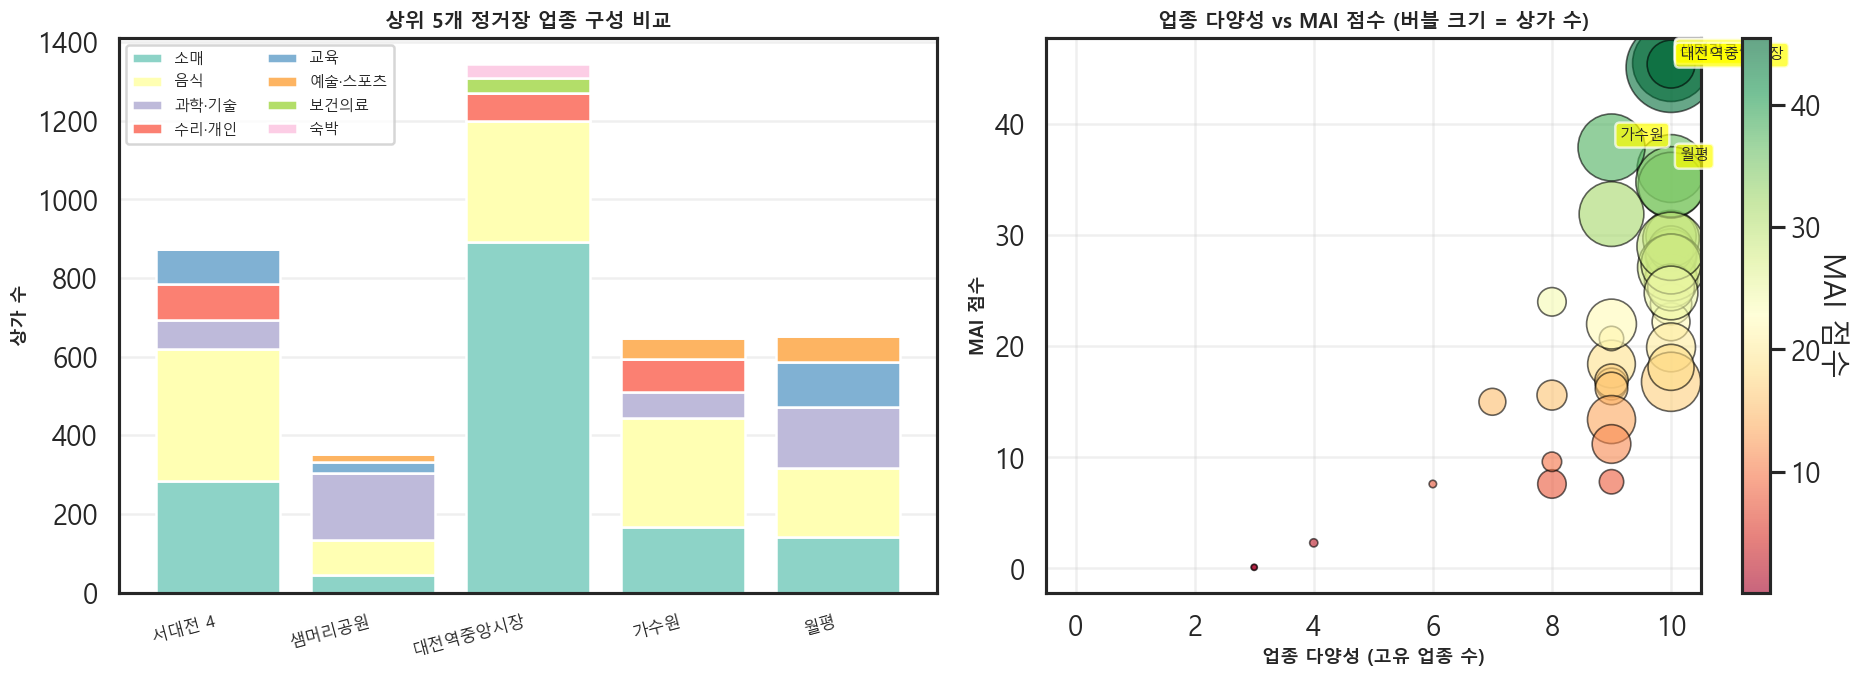


✅ 업종 다양성 분석 완료


In [ ]:
# ====== 9.5 상가 업종 다양성 분석 (레이더 차트) ======
print(f"\n{'='*70}")
print(f"🎨 트램 정거장 주변 업종 구성 분석")
print(f"{'='*70}")

# 상위 MAI 정거장 5개의 업종 분포 분석
top5_stations = tram_mai.nlargest(5, 'MAI_점수')

print("\n📊 상위 5개 정거장 업종 다양성:")
print("-"*70)

# 각 정거장별 업종 분포
station_industry_data = []

for idx, station_row in top5_stations.iterrows():
    station_name = station_row['정거장명']
    station_lat = station_row['위도']
    station_lon = station_row['경도']
    
    # 반경 400m 내 상가의 업종 분포
    nearby_industries = []
    for _, poi_row in poi.iterrows():
        if pd.notna(poi_row['위도']) and pd.notna(poi_row['경도']):
            distance = haversine(station_lat, station_lon, 
                               poi_row['위도'], poi_row['경도'])
            if distance <= 400:
                if pd.notna(poi_row['상권업종대분류명']):
                    nearby_industries.append(poi_row['상권업종대분류명'])
    
    # 업종별 개수
    from collections import Counter
    industry_counts = Counter(nearby_industries)
    
    # 상위 5개 업종
    top5_industries = dict(industry_counts.most_common(5))
    
    station_industry_data.append({
        '정거장명': station_name,
        'MAI_점수': station_row['MAI_점수'],
        '업종분포': top5_industries,
        '총상가수': len(nearby_industries),
        '업종다양성': len(set(nearby_industries))
    })
    
    print(f"\n🚊 {station_name} (MAI: {station_row['MAI_점수']:.1f}점)")
    print(f"   총 상가: {len(nearby_industries)}개, 업종 수: {len(set(nearby_industries))}개")
    print(f"   주요 업종:")
    for industry, count in industry_counts.most_common(5):
        pct = count / len(nearby_industries) * 100
        print(f"     - {industry}: {count}개 ({pct:.1f}%)")

# 시각화 1: 상위 5개 정거장 업종 구성 비교 (스택 바)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 모든 업종 수집
all_industries = set()
for data in station_industry_data:
    all_industries.update(data['업종분포'].keys())

# 상위 8개 주요 업종만 선택
industry_totals = {}
for industry in all_industries:
    industry_totals[industry] = sum([data['업종분포'].get(industry, 0) 
                                     for data in station_industry_data])

top_industries = sorted(industry_totals.items(), key=lambda x: x[1], reverse=True)[:8]
top_industry_names = [ind[0] for ind in top_industries]

# 데이터 준비
station_names = [data['정거장명'] for data in station_industry_data]
industry_matrix = []

for industry in top_industry_names:
    industry_values = [data['업종분포'].get(industry, 0) for data in station_industry_data]
    industry_matrix.append(industry_values)

# 스택 바 차트
bottom = [0] * len(station_names)
colors_ind = plt.cm.Set3(range(len(top_industry_names)))

for i, (industry, values) in enumerate(zip(top_industry_names, industry_matrix)):
    ax1.bar(range(len(station_names)), values, bottom=bottom, 
           label=industry[:10], color=colors_ind[i], 
           edgecolor='white', linewidth=1.5)
    bottom = [b + v for b, v in zip(bottom, values)]

ax1.set_xticks(range(len(station_names)))
ax1.set_xticklabels([name[:8] for name in station_names], 
                    rotation=15, ha='right', fontsize=10)
ax1.set_ylabel('상가 수', fontsize=11, weight='bold')
ax1.set_title('상위 5개 정거장 업종 구성 비교', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9, ncol=2)
ax1.grid(axis='y', alpha=0.3)

# 시각화 2: 업종 다양성 vs MAI 점수
all_stations_diversity = []
for idx, row in tram_mai.iterrows():
    all_stations_diversity.append({
        '정거장명': row['정거장명'],
        'MAI_점수': row['MAI_점수'],
        '업종다양성': row['업종다양성'],
        '상가수': row['상가수']
    })

diversity_df = pd.DataFrame(all_stations_diversity)

# 산점도 (버블 차트)
scatter = ax2.scatter(diversity_df['업종다양성'], 
                     diversity_df['MAI_점수'],
                     s=diversity_df['상가수'] * 2,  # 상가 수에 비례
                     c=diversity_df['MAI_점수'],
                     cmap='RdYlGn',
                     alpha=0.6,
                     edgecolors='black',
                     linewidths=1)

# 상위 5개 라벨링
for data in station_industry_data:
    x = diversity_df[diversity_df['정거장명'] == data['정거장명']]['업종다양성'].values[0]
    y = data['MAI_점수']
    ax2.annotate(data['정거장명'][:8], 
                xy=(x, y),
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax2.set_xlabel('업종 다양성 (고유 업종 수)', fontsize=11, weight='bold')
ax2.set_ylabel('MAI 점수', fontsize=11, weight='bold')
ax2.set_title('업종 다양성 vs MAI 점수 (버블 크기 = 상가 수)', 
             fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 컬러바
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('MAI 점수', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

print("\n✅ 업종 다양성 분석 완료")


📊 트램 2호선 멀티모달 접근성 종합 대시보드

🎯 핵심 지표 (KPI)
────────────────────────────────────────────────────────────────────────────────
   총 정거장 수: 45개
   평균 MAI 점수: 22.5점 / 100점
   우수 정거장 (70점 이상): 0개 (0.0%)
   긴급 개선 필요: 5개 (11.1%)

🚌 교통 인프라 현황
────────────────────────────────────────────────────────────────────────────────
   평균 버스 정류장: 1.0개 (반경 400m)
   평균 타슈 스테이션: 7.1개
   평균 타슈 거치대: 12개
   타슈 미연계 정거장: 2개

🏪 상권 현황
────────────────────────────────────────────────────────────────────────────────
   평균 상가 수: 416개 (반경 400m)
   평균 업종 다양성: 8.8개 업종
   최대 상가 밀집: 1457개 (대전역중앙시장)

✅ 종합 대시보드 생성 완료
   저장 경로: 트램_MAI_종합대시보드.png



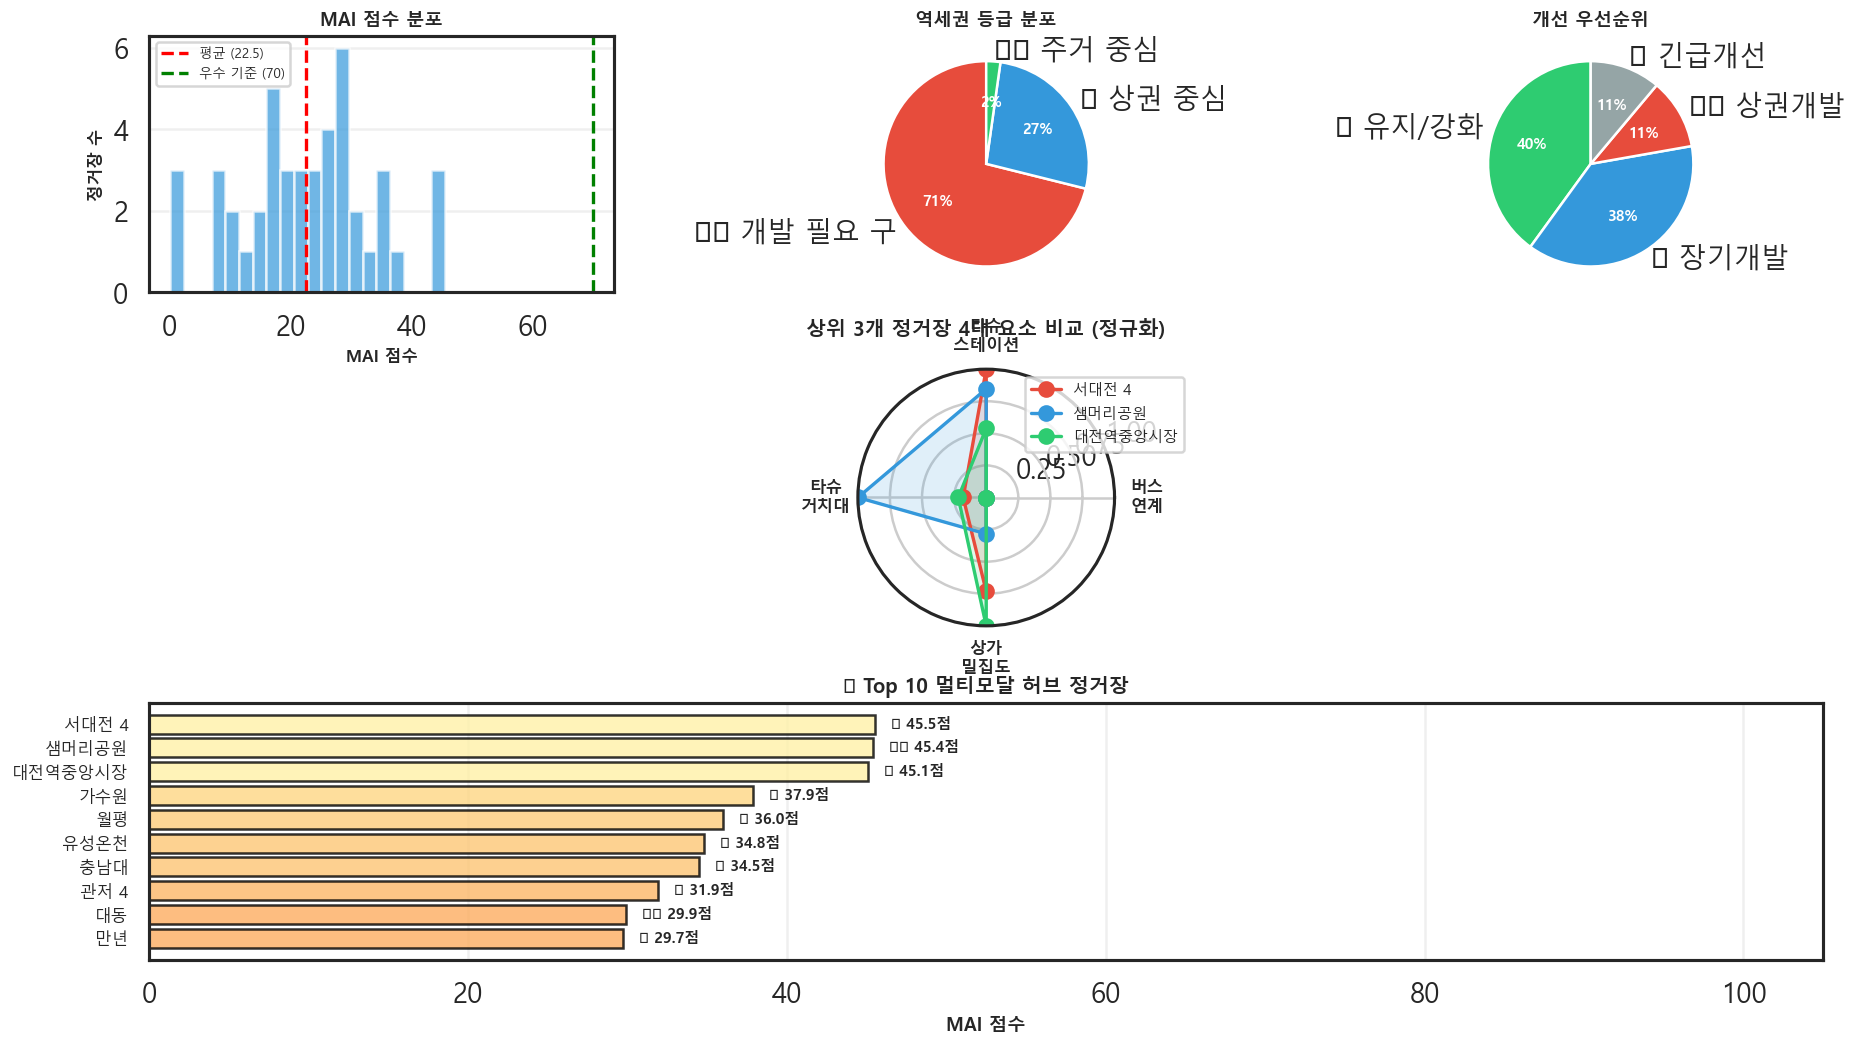

In [183]:
# ====== 9.6 종합 대시보드 (핵심 지표 요약) ======
print(f"\n{'='*80}")
print(f"📊 트램 2호선 멀티모달 접근성 종합 대시보드")
print(f"{'='*80}")

# 핵심 통계
total_stations = len(tram_mai)
avg_mai = tram_mai['MAI_점수'].mean()
excellent_stations = (tram_mai['MAI_점수'] >= 70).sum()
urgent_stations = len(tram_mai[tram_mai['개선우선순위'] == '🚨 긴급개선 (Low MAI-High 상가)'])

print(f"\n🎯 핵심 지표 (KPI)")
print(f"{'─'*80}")
print(f"   총 정거장 수: {total_stations}개")
print(f"   평균 MAI 점수: {avg_mai:.1f}점 / 100점")
print(f"   우수 정거장 (70점 이상): {excellent_stations}개 ({excellent_stations/total_stations*100:.1f}%)")
print(f"   긴급 개선 필요: {urgent_stations}개 ({urgent_stations/total_stations*100:.1f}%)")

# 교통 인프라 통계
print(f"\n🚌 교통 인프라 현황")
print(f"{'─'*80}")
print(f"   평균 버스 정류장: {tram_mai['버스정류장수'].mean():.1f}개 (반경 400m)")
print(f"   평균 타슈 스테이션: {tram_mai['타슈스테이션수'].mean():.1f}개")
print(f"   평균 타슈 거치대: {tram_mai['타슈거치대수'].mean():.0f}개")
print(f"   타슈 미연계 정거장: {(tram_mai['타슈스테이션수'] == 0).sum()}개")

# 상권 통계
print(f"\n🏪 상권 현황")
print(f"{'─'*80}")
print(f"   평균 상가 수: {tram_mai['상가수'].mean():.0f}개 (반경 400m)")
print(f"   평균 업종 다양성: {tram_mai['업종다양성'].mean():.1f}개 업종")
print(f"   최대 상가 밀집: {tram_mai['상가수'].max():.0f}개 ({tram_mai.loc[tram_mai['상가수'].idxmax(), '정거장명']})")

# 시각화: 종합 대시보드
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. MAI 점수 분포 히스토그램
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(tram_mai['MAI_점수'], bins=20, color='#3498db', 
        edgecolor='white', linewidth=1.5, alpha=0.7)
ax1.axvline(x=avg_mai, color='red', linestyle='--', linewidth=2, 
           label=f'평균 ({avg_mai:.1f})')
ax1.axvline(x=70, color='green', linestyle='--', linewidth=2, 
           label='우수 기준 (70)')
ax1.set_xlabel('MAI 점수', fontsize=10, weight='bold')
ax1.set_ylabel('정거장 수', fontsize=10, weight='bold')
ax1.set_title('MAI 점수 분포', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# 2. 역세권 등급 파이차트
ax2 = fig.add_subplot(gs[0, 1])
grade_counts = tram_mai['역세권등급'].value_counts()
colors_pie = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#95a5a6', '#bdc3c7']
wedges, texts, autotexts = ax2.pie(grade_counts.values, 
                                     labels=[g.split('(')[0].strip()[:10] for g in grade_counts.index],
                                     autopct='%1.0f%%',
                                     colors=colors_pie[:len(grade_counts)],
                                     startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_fontsize(9)
ax2.set_title('역세권 등급 분포', fontsize=11, fontweight='bold')

# 3. 개선 우선순위 파이차트
ax3 = fig.add_subplot(gs[0, 2])
priority_counts = tram_mai['개선우선순위'].value_counts()
colors_priority = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
wedges, texts, autotexts = ax3.pie(priority_counts.values,
                                     labels=[p.split('(')[0].strip() for p in priority_counts.index],
                                     autopct='%1.0f%%',
                                     colors=colors_priority[:len(priority_counts)],
                                     startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_fontsize(9)
ax3.set_title('개선 우선순위', fontsize=11, fontweight='bold')

# 4. 4가지 요소 비교 (레이더 차트)
ax4 = fig.add_subplot(gs[1, :], projection='polar')

# 상위 3개 정거장 비교
top3 = tram_mai.nlargest(3, 'MAI_점수')
categories = ['버스\n연계', '타슈\n스테이션', '타슈\n거치대', '상가\n밀집도']
angles = [n / 4 * 2 * 3.14159 for n in range(4)]
angles += angles[:1]

colors_radar = ['#e74c3c', '#3498db', '#2ecc71']
for i, (idx, row) in enumerate(top3.iterrows()):
    values = [
        row['버스_norm'],
        row['타슈스테이션_norm'],
        row['타슈거치대_norm'],
        row['상가_norm']
    ]
    values += values[:1]
    
    ax4.plot(angles, values, 'o-', linewidth=2, label=row['정거장명'], 
            color=colors_radar[i])
    ax4.fill(angles, values, alpha=0.15, color=colors_radar[i])

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(categories, fontsize=10, weight='bold')
ax4.set_ylim(0, 1)
ax4.set_title('상위 3개 정거장 4대 요소 비교 (정규화)', 
             fontsize=12, fontweight='bold', pad=20)
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
ax4.grid(True)

# 5. Top 10 정거장 랭킹
ax5 = fig.add_subplot(gs[2, :])
top10 = tram_mai.nlargest(10, 'MAI_점수')
y_pos = range(len(top10))
colors_rank = plt.cm.RdYlGn(top10['MAI_점수'] / 100)

bars = ax5.barh(y_pos, top10['MAI_점수'], color=colors_rank, 
               edgecolor='black', linewidth=1.5, alpha=0.8)

# 등급 표시
for i, (idx, row) in enumerate(top10.iterrows()):
    grade_icon = row['역세권등급'].split()[0]
    ax5.text(row['MAI_점수'] + 1, i, f"{grade_icon} {row['MAI_점수']:.1f}점", 
            va='center', fontsize=9, weight='bold')

ax5.set_yticks(y_pos)
ax5.set_yticklabels(top10['정거장명'], fontsize=10)
ax5.set_xlabel('MAI 점수', fontsize=11, weight='bold')
ax5.set_title('🏆 Top 10 멀티모달 허브 정거장', fontsize=12, fontweight='bold')
ax5.set_xlim(0, 105)
ax5.grid(axis='x', alpha=0.3)
ax5.invert_yaxis()

#plt.suptitle('대전 트램 2호선 멀티모달 접근성 종합 대시보드', 
            #fontsize=16, fontweight='bold', y=0.98)

#plt.savefig('C:/Users/THKIM/Desktop/3-2 프로젝트/스마트시티 문제해결 프로젝트/트램_MAI_종합대시보드.png',
           #dpi=300, bbox_inches='tight', facecolor='white')
#plt.show()

print(f"\n✅ 종합 대시보드 생성 완료")
print(f"   저장 경로: 트램_MAI_종합대시보드.png")
print(f"{'='*80}\n")